**Aline Gabriel de Almeida**

# **The Verification Problem in Compute Governance**



## **Setup and global configuration**

In [7]:
!pip install aeon

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 59.8 MB/s eta 0:00:00


In [8]:
# =============================================================================
# Setup and global configuration
# =============================================================================

from google.colab import drive
drive.mount("/content/drive")

import os
import glob
from pathlib import Path
from typing import Dict, Any, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.interpolate import interp1d
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# MiniRocket
# If needed, uncomment the next line once in Colab:
# !pip install -q aeon

from aeon.classification.convolution_based import MiniRocketClassifier

sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "figure.dpi": 140,
    "font.size": 8,
    "axes.titlesize": 10,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "lines.linewidth": 1.2,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

EPS = 1e-12
RANDOM_STATE = 42

Mounted at /content/drive


## **Paths, metadata, and analysis parameters**

In [9]:
# =============================================================================
# Paths, metadata, and analysis parameters
# =============================================================================

RUN_PATHS = {
    "llm_training": "/content/drive/MyDrive/AI safety/BlueDot/2 - Technical AI Safety Project/data training LLM/gpowerSAMPLER",
    "llm_inference": "/content/drive/MyDrive/AI safety/BlueDot/2 - Technical AI Safety Project/data inference_LLM/gpowerSAMPLER",
    "transformer_non_llm_training": "/content/drive/MyDrive/AI safety/BlueDot/2 - Technical AI Safety Project/training non-llm transformer (bert)/gpowerSAMPLER",
    "resnet_training": "/content/drive/MyDrive/AI safety/BlueDot/2 - Technical AI Safety Project/data ResNet50 training/data_sampler/gpowerSAMPLER",
}

RUN_DISPLAY_NAMES = {
    "llm_training": "LLM Training",
    "llm_inference": "LLM Inference",
    "transformer_non_llm_training": "MLM Training ",
    "resnet_training": "CNN Training",
}

WORKLOAD_ORDER = [
    "llm_training",
    "transformer_non_llm_training",
    "resnet_training",
    "llm_inference",
]

WORKLOAD_COLORS = {
    "llm_training": "#f54294",
    "transformer_non_llm_training": "#8b5cf6",
    "resnet_training": "#00bfff",
    "llm_inference": "#f56a1c",
}

SIGNAL_CONFIG = {
    "gpu_util": {
        "label": "GPU Utilization (%)",
        "unit": "%",
        "plot_unit_label": "%",
        "order": 0,
    },
    "power": {
        "label": "Power (mW)",
        "unit": "mW",
        "plot_unit_label": "mW",
        "order": 1,
    },
    "temperature": {
        "label": "Temperature (°C)",
        "unit": "°C",
        "plot_unit_label": "°C",
        "order": 2,
    },
    "sm_clock": {
        "label": "SM Clock (MHz)",
        "unit": "MHz",
        "plot_unit_label": "MHz",
        "order": 3,
    },
    "pcie_tx": {
        "label": "PCIe TX (KB/s)",
        "unit": "KB/s",
        "plot_unit_label": "KB/s",
        "order": 4,
    },
}

PRIMARY_SIGNALS = ["gpu_util", "power", "temperature", "sm_clock", "pcie_tx"]

# -------------------------------------------------------------------------
# Trimming policy
# -------------------------------------------------------------------------
# The purpose of this trimming is not automatic detection.
# It is a manual experimental choice to exclude non-steady-state regions.
#
# - LLM training: remove the long initial loading / setup phase by time.
# - Other workloads: remove the first 100 samples to avoid initial transient behavior.
TRIM_CONFIG = {
    "llm_training": {"trim_start_seconds": 2800.0, "trim_first_n": 0},
    "llm_inference": {"trim_start_seconds": None, "trim_first_n": 300},
    "transformer_non_llm_training": {"trim_start_seconds": None, "trim_first_n": 300},
    "resnet_training": {"trim_start_seconds": None, "trim_first_n": 300},
}

# -------------------------------------------------------------------------
# Resampling and windowing
# -------------------------------------------------------------------------
TARGET_RESAMPLE_HZ = 20.0

WINDOW_SIZE_S = 40.0
WINDOW_STEP_S = 40.0

# Optional paper-style short raw view
SHORT_VIEW_START_S = 300.0
SHORT_VIEW_DURATION_S = 40.0

# Temporal blocked split for preliminary evaluation
TRAIN_FRACTION = 0.7
TEST_FRACTION = 0.3

## **Loading telemetry**

In [10]:
# =============================================================================
# Loading and trimming telemetry
# =============================================================================

def detect_signal_type(filename: str) -> Optional[str]:
    name = filename.lower()

    if "gpu_util" in name:
        return "gpu_util"
    if "power" in name:
        return "power"
    if "temperature" in name:
        return "temperature"
    if "sm_clock" in name:
        return "sm_clock"
    if "pcie_tx" in name:
        return "pcie_tx"

    return None


def convert_time_to_seconds(raw_time: pd.Series) -> pd.Series:
    raw_time = pd.to_numeric(raw_time, errors="coerce").dropna()

    if raw_time.empty:
        raise ValueError("Time column is empty after numeric conversion.")

    max_time = raw_time.max()

    # Heuristic based on observed telemetry timestamp scales.
    if max_time > 1e12:
        time_s = raw_time / 1e9
    elif max_time > 1e9:
        time_s = raw_time / 1e6
    elif max_time > 1e6:
        time_s = raw_time / 1e3
    else:
        time_s = raw_time.astype(float)

    return time_s - time_s.iloc[0]


def remove_absurd_outliers(series: pd.Series, signal_type: str) -> pd.Series:
    """
    Extremely conservative cleaning.
    Only removes impossible values, keeps all real signal dynamics.
    """

    s = pd.to_numeric(series, errors="coerce").astype(float)

    # Physical lower bounds
    lower_bounds = {
        "gpu_util": 0.0,
        "power": 0.0,
        "temperature": 0.0,
        "sm_clock": 0.0,
        "pcie_tx": 0.0,
    }

    lb = lower_bounds.get(signal_type, -np.inf)
    s = s.clip(lower=lb)

    # Very loose upper bounds (only removes absurd spikes)
    upper_bounds = {
        "gpu_util": 100.0,
        "power": 1_000_000.0,       # 1 kW (way above real A100)
        "temperature": 120.0,       # impossible in practice
        "sm_clock": 5000.0,         # well above hardware limits
        "pcie_tx": 1_000_000.0,     # 1 GB/s (extremely high but safe cap)
    }

    ub = upper_bounds.get(signal_type, np.inf)
    s = s.clip(upper=ub)

    return s


def load_single_telemetry_csv(path: str, run_name: str) -> Dict[str, Any]:
    df = pd.read_csv(path, sep=";", skiprows=1)
    df.columns = [c.strip() for c in df.columns]

    time_candidates = [c for c in df.columns if "time" in c.lower()]
    if not time_candidates:
        raise ValueError(f"No time column found in {path}")

    time_col = time_candidates[0]
    value_candidates = [c for c in df.columns if c != time_col]

    if len(value_candidates) != 1:
        raise ValueError(f"Expected one value column in {path}, found {value_candidates}")

    value_col = value_candidates[0]

    df[time_col] = pd.to_numeric(df[time_col], errors="coerce")
    df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
    df = df.dropna(subset=[time_col, value_col]).reset_index(drop=True)

    if df.empty:
        raise ValueError(f"No valid rows found in {path}")

    df["time_s"] = convert_time_to_seconds(df[time_col])

    signal_type = detect_signal_type(os.path.basename(path))
    if signal_type is None:
        raise ValueError(f"Could not detect signal type for file: {path}")

    # Remove only extremely implausible spikes
    df[value_col] = remove_absurd_outliers(df[value_col], signal_type)

    trim_cfg = TRIM_CONFIG[run_name]

    # LLM training: trim by time to remove loading / warmup
    if trim_cfg["trim_start_seconds"] is not None:
        df = df[df["time_s"] >= trim_cfg["trim_start_seconds"]].copy()

    # Other workloads: drop the first N samples to remove initial transient behavior
    trim_first_n = int(trim_cfg.get("trim_first_n", 0))
    if trim_first_n > 0:
        if len(df) <= trim_first_n:
            raise ValueError(
                f"File has only {len(df)} rows after time trimming, cannot drop first {trim_first_n} rows: {path}"
            )
        df = df.iloc[trim_first_n:].copy()

    df = df.reset_index(drop=True)

    if df.empty:
        raise ValueError(f"File became empty after trimming: {path}")

    # Re-align time after trimming so every run starts at t = 0 in the kept region
    df["time_s"] = df["time_s"] - df["time_s"].iloc[0]

    return {
        "df": df,
        "time_col": time_col,
        "value_col": value_col,
        "signal_type": signal_type,
        "source_file": os.path.basename(path),
    }


def load_run_folder(folder_path: str, run_name: str) -> Dict[str, Dict[str, Any]]:
    if not os.path.exists(folder_path):
        print(f"[WARNING] Folder does not exist: {folder_path}")
        return {}

    csv_files = sorted(glob.glob(os.path.join(folder_path, "*.csv")))
    if not csv_files:
        print(f"[WARNING] No CSV files found in: {folder_path}")
        return {}

    run_data = {}

    for path in csv_files:
        try:
            content = load_single_telemetry_csv(path, run_name=run_name)
            signal_type = content["signal_type"]

            if signal_type in PRIMARY_SIGNALS:
                run_data[signal_type] = content
                print(f"[OK] Loaded {run_name} / {signal_type}")
        except Exception as exc:
            print(f"[ERROR] Failed to load {os.path.basename(path)}: {exc}")

    return run_data


def load_all_runs(run_paths: Dict[str, str]) -> Dict[str, Dict[str, Dict[str, Any]]]:
    all_runs = {}

    for run_name in WORKLOAD_ORDER:
        print(f"\n=== Loading {run_name} ===")
        all_runs[run_name] = load_run_folder(run_paths[run_name], run_name)

    return all_runs


all_runs = load_all_runs(RUN_PATHS)


=== Loading llm_training ===
[OK] Loaded llm_training / gpu_util
[ERROR] Failed to load telemetry_mem_clock_data.csv: Could not detect signal type for file: /content/drive/MyDrive/AI safety/BlueDot/2 - Technical AI Safety Project/data training LLM/gpowerSAMPLER/telemetry_mem_clock_data.csv
[OK] Loaded llm_training / pcie_tx
[OK] Loaded llm_training / power
[OK] Loaded llm_training / sm_clock
[OK] Loaded llm_training / temperature

=== Loading transformer_non_llm_training ===
[OK] Loaded transformer_non_llm_training / gpu_util
[ERROR] Failed to load telemetry_mem_clock_data.csv: Could not detect signal type for file: /content/drive/MyDrive/AI safety/BlueDot/2 - Technical AI Safety Project/training non-llm transformer (bert)/gpowerSAMPLER/telemetry_mem_clock_data.csv
[OK] Loaded transformer_non_llm_training / pcie_tx
[OK] Loaded transformer_non_llm_training / power
[OK] Loaded transformer_non_llm_training / sm_clock
[OK] Loaded transformer_non_llm_training / temperature

=== Loading res

## **Data inventory and sanity checks**

In [11]:
# =============================================================================
# Data inventory and sanity checks
# =============================================================================

def summarize_loaded_runs(all_runs: Dict[str, Dict[str, Dict[str, Any]]]) -> pd.DataFrame:
    rows = []

    for run_name in WORKLOAD_ORDER:
        run_data = all_runs.get(run_name, {})

        for signal_type in PRIMARY_SIGNALS:
            content = run_data.get(signal_type)
            if content is None:
                rows.append({
                    "run_name": run_name,
                    "run_display_name": RUN_DISPLAY_NAMES[run_name],
                    "signal_type": signal_type,
                    "n_samples": 0,
                    "duration_s": np.nan,
                    "source_file": None,
                })
                continue

            df = content["df"]
            rows.append({
                "run_name": run_name,
                "run_display_name": RUN_DISPLAY_NAMES[run_name],
                "signal_type": signal_type,
                "n_samples": len(df),
                "duration_s": float(df["time_s"].max()) if len(df) else np.nan,
                "source_file": content["source_file"],
            })

    out = pd.DataFrame(rows)
    out["signal_order"] = out["signal_type"].map({k: v["order"] for k, v in SIGNAL_CONFIG.items()})
    out = out.sort_values(["run_name", "signal_order"], kind="stable").drop(columns="signal_order")
    return out.reset_index(drop=True)


inventory_df = summarize_loaded_runs(all_runs)
display(inventory_df)

,run_name,run_display_name,signal_type,n_samples,duration_s,source_file
0,llm_inference,LLM Inference,gpu_util,172605,3594.048609,telemetry_gpu_util_data.csv
1,llm_inference,LLM Inference,power,172605,3594.048609,telemetry_power_mw_data.csv
2,llm_inference,LLM Inference,temperature,172605,3594.048609,telemetry_temperature_data.csv
3,llm_inference,LLM Inference,sm_clock,172605,3594.048609,telemetry_sm_clock_data.csv
4,llm_inference,LLM Inference,pcie_tx,172605,3594.048609,telemetry_pcie_tx_data.csv
5,llm_training,LLM Training,gpu_util,149110,4401.828705,telemetry_gpu_util_data.csv
6,llm_training,LLM Training,power,149110,4401.828705,telemetry_power_mw_data.csv
7,llm_training,LLM Training,temperature,149110,4401.828705,telemetry_temperature_data.csv
8,llm_training,LLM Training,sm_clock,149110,4401.828705,telemetry_sm_clock_data.csv
9,llm_training,LLM Training,pcie_tx,149110,4401.828705,telemetry_pcie_tx_data.csv


In [12]:
def compute_sampling_stats(time_s: np.ndarray) -> Dict[str, float]:
    time_s = np.asarray(time_s, dtype=float)

    if len(time_s) < 2:
        return {
            "median_dt_s": np.nan,
            "mean_dt_s": np.nan,
            "p95_dt_s": np.nan,
            "effective_fs_hz": np.nan,
        }

    dt = np.diff(time_s)
    dt = dt[np.isfinite(dt) & (dt > 0)]

    if len(dt) == 0:
        return {
            "median_dt_s": np.nan,
            "mean_dt_s": np.nan,
            "p95_dt_s": np.nan,
            "effective_fs_hz": np.nan,
        }

    median_dt = float(np.median(dt))
    return {
        "median_dt_s": median_dt,
        "mean_dt_s": float(np.mean(dt)),
        "p95_dt_s": float(np.percentile(dt, 95)),
        "effective_fs_hz": float(1.0 / median_dt) if median_dt > 0 else np.nan,
    }


def summarize_sampling_quality(all_runs: Dict[str, Dict[str, Dict[str, Any]]]) -> pd.DataFrame:
    rows = []

    for run_name in WORKLOAD_ORDER:
        for signal_type in PRIMARY_SIGNALS:
            content = all_runs.get(run_name, {}).get(signal_type)
            if content is None:
                continue

            df = content["df"]
            stats = compute_sampling_stats(df["time_s"].to_numpy())

            rows.append({
                "run_name": run_name,
                "run_display_name": RUN_DISPLAY_NAMES[run_name],
                "signal_type": signal_type,
                **stats,
            })

    out = pd.DataFrame(rows)
    out["signal_order"] = out["signal_type"].map({k: v["order"] for k, v in SIGNAL_CONFIG.items()})
    out = out.sort_values(["run_name", "signal_order"], kind="stable").drop(columns="signal_order")
    return out.reset_index(drop=True)


sampling_quality_df = summarize_sampling_quality(all_runs)
display(sampling_quality_df)

,run_name,run_display_name,signal_type,median_dt_s,mean_dt_s,p95_dt_s,effective_fs_hz
0,llm_inference,LLM Inference,gpu_util,0.020584,0.020823,0.022426,48.581422
1,llm_inference,LLM Inference,power,0.020584,0.020823,0.022426,48.581422
2,llm_inference,LLM Inference,temperature,0.020584,0.020823,0.022426,48.581422
3,llm_inference,LLM Inference,sm_clock,0.020584,0.020823,0.022426,48.581422
4,llm_inference,LLM Inference,pcie_tx,0.020584,0.020823,0.022426,48.581422
5,llm_training,LLM Training,gpu_util,0.020573,0.029521,0.022558,48.607398
6,llm_training,LLM Training,power,0.020573,0.029521,0.022558,48.607398
7,llm_training,LLM Training,temperature,0.020573,0.029521,0.022558,48.607398
8,llm_training,LLM Training,sm_clock,0.020573,0.029521,0.022558,48.607398
9,llm_training,LLM Training,pcie_tx,0.020573,0.029521,0.022558,48.607398


In [13]:
# =============================================================================
# PCIe TX audit: raw loaded values and scale consistency check
# =============================================================================

def audit_single_signal(run_name: str, signal_type: str = "pcie_tx") -> pd.DataFrame:
    content = all_runs[run_name][signal_type]
    df = content["df"]
    value_col = content["value_col"]

    s = pd.to_numeric(df[value_col], errors="coerce")

    out = pd.DataFrame([{
        "run_name": run_name,
        "run_display_name": RUN_DISPLAY_NAMES[run_name],
        "source_file": content["source_file"],
        "value_col": value_col,
        "n_samples": len(df),
        "min": float(s.min()),
        "p01": float(s.quantile(0.01)),
        "p05": float(s.quantile(0.05)),
        "median": float(s.median()),
        "p95": float(s.quantile(0.95)),
        "p99": float(s.quantile(0.99)),
        "max": float(s.max()),
        "mean": float(s.mean()),
        "std": float(s.std()),
    }])

    return out


pcie_audit_df = pd.concat([
    audit_single_signal("llm_training", "pcie_tx"),
    audit_single_signal("transformer_non_llm_training", "pcie_tx"),
], ignore_index=True)

display(pcie_audit_df)

,run_name,run_display_name,source_file,value_col,n_samples,min,p01,p05,median,p95,p99,max,mean,std
0,llm_training,LLM Training,telemetry_pcie_tx_data.csv,pcie_tx_KBps,149110,244.0,2636.0,3222.0,4638.0,6982.0,267285.0,301269.0,9919.868520,36525.810262
1,transformer_non_llm_training,MLM Training,telemetry_pcie_tx_data.csv,pcie_tx_KBps,128147,244.0,3271.0,4003.0,5078.0,9472.0,247070.0,266943.0,10012.646195,33391.404478


In [14]:
for run_name in ["llm_training", "transformer_non_llm_training"]:
    content = all_runs[run_name]["pcie_tx"]
    print("=" * 80)
    print("Run:", run_name)
    print("Display name:", RUN_DISPLAY_NAMES[run_name])
    print("Source file:", content["source_file"])
    print("Detected signal type:", content["signal_type"])
    print("Value column:", content["value_col"])
    print(content["df"].head())

Run: llm_training
Display name: LLM Training
Source file: telemetry_pcie_tx_data.csv
Detected signal type: pcie_tx
Value column: pcie_tx_KBps
   timestamp_us  pcie_tx_KBps    time_s
0    5513868952        5078.0  0.000000
1    5513889420        4589.0  0.020468
2    5513909992        4394.0  0.041040
3    5513930389        4638.0  0.061437
4    5513950971        4541.0  0.082019
Run: transformer_non_llm_training
Display name: MLM Training 
Source file: telemetry_pcie_tx_data.csv
Detected signal type: pcie_tx
Value column: pcie_tx_KBps
   timestamp_us  pcie_tx_KBps    time_s
0   11159669657         292.0  0.000000
1   11159689942         292.0  0.020285
2   11159710229         292.0  0.040572
3   11159730517         634.0  0.060860
4   11159750848         292.0  0.081191


In [15]:
def load_single_telemetry_csv_no_outlier_clipping(path: str, run_name: str) -> Dict[str, Any]:
    df = pd.read_csv(path, sep=";", skiprows=1)
    df.columns = [c.strip() for c in df.columns]

    time_candidates = [c for c in df.columns if "time" in c.lower()]
    if not time_candidates:
        raise ValueError(f"No time column found in {path}")

    time_col = time_candidates[0]
    value_candidates = [c for c in df.columns if c != time_col]

    if len(value_candidates) != 1:
        raise ValueError(f"Expected one value column in {path}, found {value_candidates}")

    value_col = value_candidates[0]

    df[time_col] = pd.to_numeric(df[time_col], errors="coerce")
    df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
    df = df.dropna(subset=[time_col, value_col]).reset_index(drop=True)

    df["time_s"] = convert_time_to_seconds(df[time_col])

    signal_type = detect_signal_type(os.path.basename(path))

    trim_cfg = TRIM_CONFIG[run_name]

    if trim_cfg["trim_start_seconds"] is not None:
        df = df[df["time_s"] >= trim_cfg["trim_start_seconds"]].copy()

    trim_first_n = int(trim_cfg.get("trim_first_n", 0))
    if trim_first_n > 0:
        df = df.iloc[trim_first_n:].copy()

    df = df.reset_index(drop=True)
    df["time_s"] = df["time_s"] - df["time_s"].iloc[0]

    return {
        "df": df,
        "time_col": time_col,
        "value_col": value_col,
        "signal_type": signal_type,
        "source_file": os.path.basename(path),
    }

In [16]:
for run_name in ["llm_training", "transformer_non_llm_training"]:
    folder = RUN_PATHS[run_name]
    csv_files = sorted(glob.glob(os.path.join(folder, "*.csv")))
    pcie_file = [p for p in csv_files if "pcie_tx" in os.path.basename(p).lower()][0]

    raw_no_clip = load_single_telemetry_csv_no_outlier_clipping(pcie_file, run_name)
    clipped = all_runs[run_name]["pcie_tx"]

    raw_s = raw_no_clip["df"][raw_no_clip["value_col"]]
    clip_s = clipped["df"][clipped["value_col"]]

    print("=" * 80)
    print(run_name)
    print("No clipping  - min/max:", float(raw_s.min()), float(raw_s.max()))
    print("With clipping - min/max:", float(clip_s.min()), float(clip_s.max()))

llm_training
No clipping  - min/max: 244.0 301269.0
With clipping - min/max: 244.0 301269.0
transformer_non_llm_training
No clipping  - min/max: 244.0 266943.0
With clipping - min/max: 244.0 266943.0


In [17]:
def plot_pcie_comparison_same_axis(run_names=("llm_training", "transformer_non_llm_training"), duration_s=60):
    fig, ax = plt.subplots(figsize=(8, 3))

    ymax = 0.0

    for run_name in run_names:
        content = all_runs[run_name]["pcie_tx"]
        df = content["df"]
        value_col = content["value_col"]

        view = df[df["time_s"] <= duration_s].copy()
        ymax = max(ymax, float(view[value_col].max()))

        ax.plot(
            view["time_s"],
            view[value_col],
            label=RUN_DISPLAY_NAMES[run_name],
            color=WORKLOAD_COLORS[run_name],
            alpha=0.9,
        )

    ax.set_ylim(0, ymax * 1.05)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("PCIe TX (KB/s)")
    ax.set_title("PCIe TX comparison on the same axis")
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()
#plot_pcie_comparison_same_axis()

## **Data overview**

### **Full signal overview**

In [18]:
def compute_shared_ylim(
    all_runs: Dict[str, Dict[str, Dict[str, Any]]],
    signal_type: str,
    use_short_view: bool = False,
    start_s: float = 0.0,
    duration_s: float = 60.0,
    pad_fraction: float = 0.04,
) -> Optional[Tuple[float, float]]:
    values = []

    end_s = start_s + duration_s

    for run_name in WORKLOAD_ORDER:
        content = all_runs.get(run_name, {}).get(signal_type)
        if content is None:
            continue

        df = content["df"]
        value_col = content["value_col"]

        if use_short_view:
            df = df[(df["time_s"] >= start_s) & (df["time_s"] <= end_s)]

        if df.empty:
            continue

        vals = pd.to_numeric(df[value_col], errors="coerce").to_numpy(dtype=float)
        vals = vals[np.isfinite(vals)]

        if len(vals) > 0:
            values.append(vals)

    if not values:
        return None

    all_values = np.concatenate(values)
    vmin = float(np.min(all_values))
    vmax = float(np.max(all_values))

    if np.isclose(vmin, vmax):
        delta = max(1.0, abs(vmin) * 0.05)
        return (vmin - delta, vmax + delta)

    pad = pad_fraction * (vmax - vmin)
    return (vmin - pad, vmax + pad)

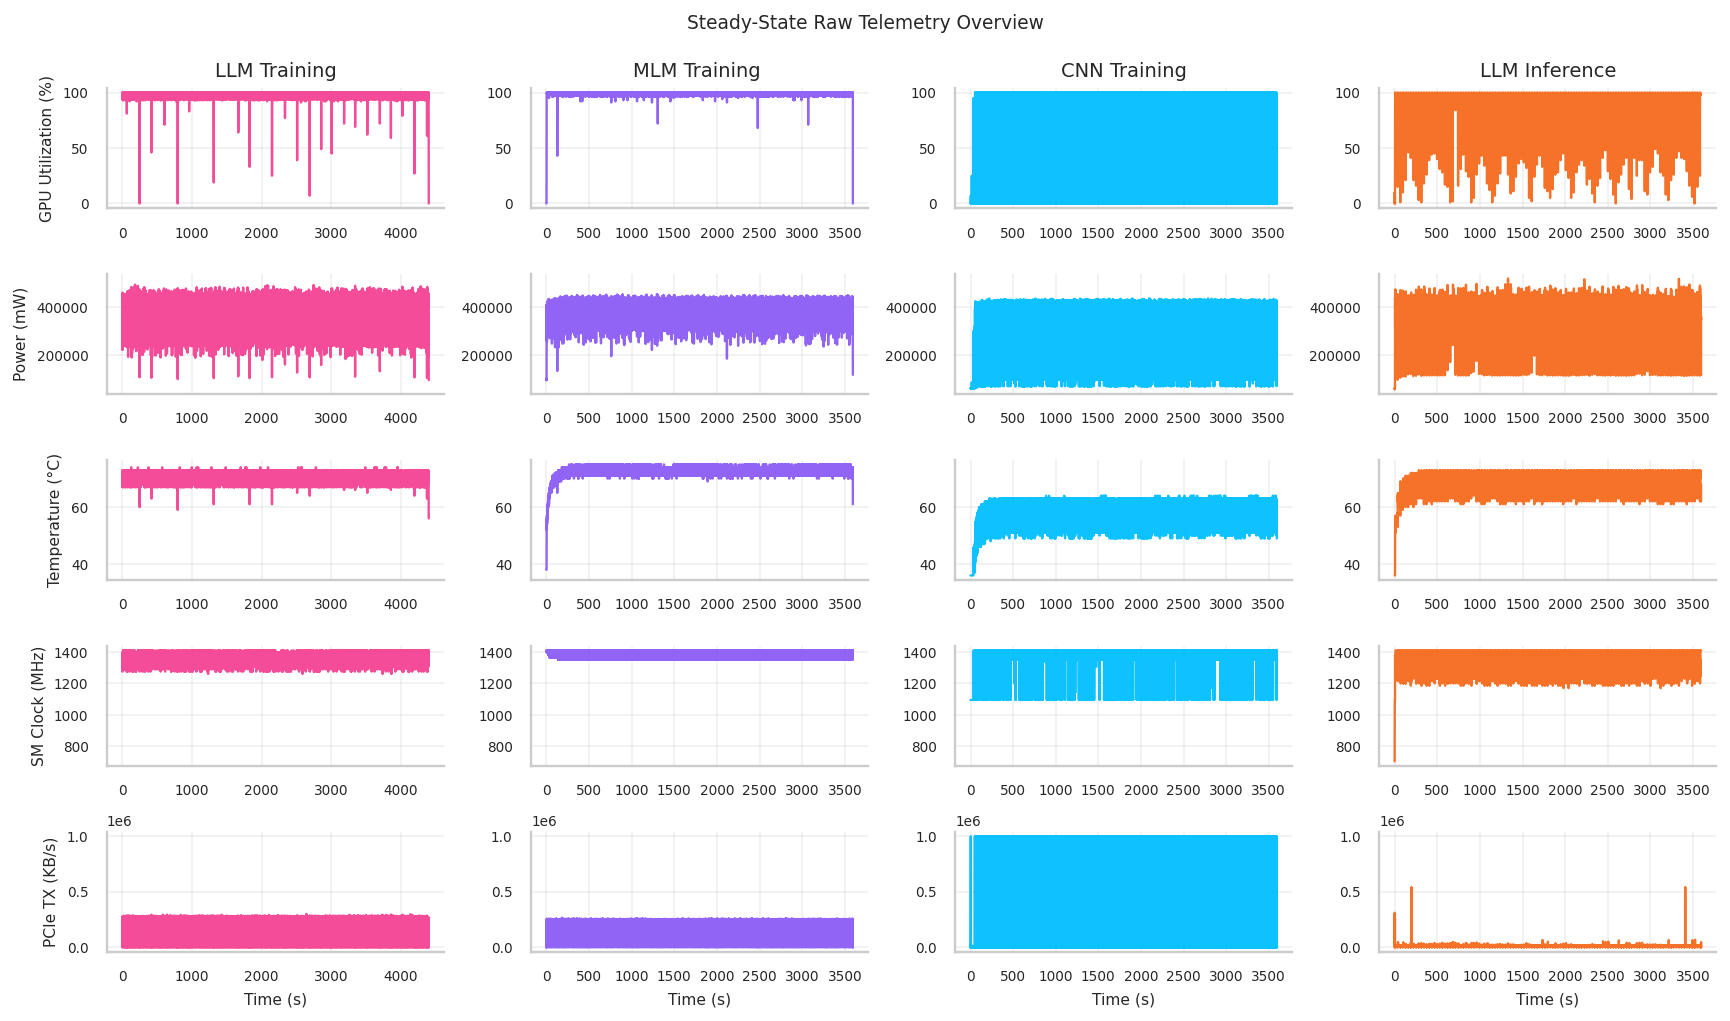

In [19]:
def plot_full_raw_overview(
    all_runs: Dict[str, Dict[str, Dict[str, Any]]],
    signals: List[str] = PRIMARY_SIGNALS,
) -> None:
    nrows = len(signals)
    ncols = len(WORKLOAD_ORDER)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(3.1 * ncols, 1.45 * nrows),
        squeeze=False,
    )

    shared_ylims = {
        signal_type: compute_shared_ylim(all_runs, signal_type, use_short_view=False)
        for signal_type in signals
    }

    for row_idx, signal_type in enumerate(signals):
        ylim = shared_ylims[signal_type]

        for col_idx, run_name in enumerate(WORKLOAD_ORDER):
            ax = axes[row_idx, col_idx]
            content = all_runs.get(run_name, {}).get(signal_type)

            if content is None:
                ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
                if row_idx == 0:
                    ax.set_title(RUN_DISPLAY_NAMES[run_name])
                continue

            df = content["df"]
            value_col = content["value_col"]

            ax.plot(
                df["time_s"],
                df[value_col],
                color=WORKLOAD_COLORS[run_name],
                alpha=0.95,
            )

            if ylim is not None:
                ax.set_ylim(*ylim)

            if row_idx == 0:
                ax.set_title(RUN_DISPLAY_NAMES[run_name])

            if col_idx == 0:
                ax.set_ylabel(SIGNAL_CONFIG[signal_type]["label"])
            else:
                ax.set_ylabel("")

            if row_idx == nrows - 1:
                ax.set_xlabel("Time (s)")

            ax.grid(True, alpha=0.25)

    fig.suptitle("Steady-State Raw Telemetry Overview", y=0.995)
    plt.tight_layout()
    plt.show()

plot_full_raw_overview(all_runs)

### **Detailed signal view**

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, Any, List, Optional

def plot_llm_training_ai2027_style(
    all_runs: Dict[str, Dict[str, Dict[str, Any]]],
    run_name: str = "llm_training",
    title: Optional[str] = None,
    start_s: float = SHORT_VIEW_START_S,
    duration_s: float = 60.0,
    signals: Optional[List[str]] = None,
    smooth: bool = False,
    smooth_window: int = 7,
    figsize_per_panel: float = 2.6,
    panel_height: float = 2.2,
    line_width: float = 1.0,
    save_path: Optional[str] = None,
    pcie_unit: str = "MB/s",   # "MB/s" ou "scientific"
) -> None:

    if signals is None:
        signals = PRIMARY_SIGNALS

    ncols = len(signals)
    fig, axes = plt.subplots(
        1, ncols,
        figsize=(figsize_per_panel * ncols, panel_height),
        squeeze=False
    )
    axes = axes[0]

    end_s = start_s + duration_s

    plt.rcParams.update({
        "font.family": "serif",
        "axes.linewidth": 0.8,
    })

    custom_labels = {
        "gpu_util": "GPU (%)",
        "power": "Power (W)",
        "temperature": "Temp (°C)",
        "sm_clock": "SM clk (GHz)",
        "pcie_tx": "PCIe TX (MB/s)" if pcie_unit == "MB/s" else "PCIe TX",
    }

    for ax, signal_type in zip(axes, signals):
        content = all_runs.get(run_name, {}).get(signal_type)

        if content is None:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
            continue

        df = content["df"]
        value_col = content["value_col"]

        view = df[(df["time_s"] >= start_s) & (df["time_s"] <= end_s)].copy()

        if view.empty:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
            continue

        x = view["time_s"].to_numpy() - start_s
        y = view[value_col].to_numpy().astype(float)

        # unit conversions
        if signal_type == "power" and np.nanmax(y) > 10000:
            y = y / 1000.0  # mW -> W

        if signal_type == "sm_clock":
            y = y / 1000.0  # MHz -> GHz

        if signal_type == "pcie_tx" and pcie_unit == "MB/s":
            y = y / 1000.0  # assuming original is KB/s -> MB/s

        # smoothing
        if smooth and len(y) >= smooth_window:
            kernel = np.ones(smooth_window) / smooth_window
            y = np.convolve(y, kernel, mode="same")

        ax.plot(
            x, y,
            color="deepskyblue", #"black",
            linewidth=line_width,
            solid_capstyle="round"
        )

        ax.set_xlim(0, duration_s)

        y_min = np.nanmin(y)
        y_max = np.nanmax(y)

        if np.isfinite(y_min) and np.isfinite(y_max):
            if y_max > y_min:
                pad = 0.08 * (y_max - y_min)
                y_lo = y_min - pad
                y_hi = y_max + pad
            else:
                pad = 0.05 * max(abs(y_max), 1.0)
                y_lo = y_min - pad
                y_hi = y_max + pad

            ax.set_ylim(y_lo, y_hi)
            ax.set_yticks([y_min, y_max])

            if signal_type == "pcie_tx" and pcie_unit == "scientific":
                def sci_2line(v):
                    s = f"{v:.1e}"
                    mantissa, exp = s.split("e")
                    return f"{mantissa}\n" + f"e{exp}"

                ax.set_yticklabels([sci_2line(y_min), sci_2line(y_max)], fontsize=10)
            else:
                def fmt(v):
                    if abs(v) >= 100:
                        return f"{int(round(v))}"
                    elif abs(v) >= 10:
                        return f"{v:.1f}"
                    else:
                        return f"{v:.2f}"

                ax.set_yticklabels([fmt(y_min), fmt(y_max)], fontsize=10)

        ax.grid(False)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.spines["bottom"].set_linewidth(0.8)

        # x axis: no numeric labels
        xticks = np.arange(0, duration_s + 1, 10)
        ax.set_xticks(xticks)
        ax.set_xticklabels([])
        ax.tick_params(axis="x", length=0, width=0.8, pad=2)
        ax.tick_params(axis="y", length=0)

        label = custom_labels.get(
            signal_type,
            SIGNAL_CONFIG.get(signal_type, {}).get("label", signal_type)
        )
        ax.set_ylabel(label, fontsize=13, labelpad=5)

    # title
    if title is None:
        title = f"{run_name} ({int(duration_s)} s)"

    fig.suptitle(
        title,
        fontsize=16,
        y=1.02
    )

    plt.subplots_adjust(
        left=0.06,
        right=0.995,
        bottom=0.18,
        top=0.80,
        wspace=0.38,
    )

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

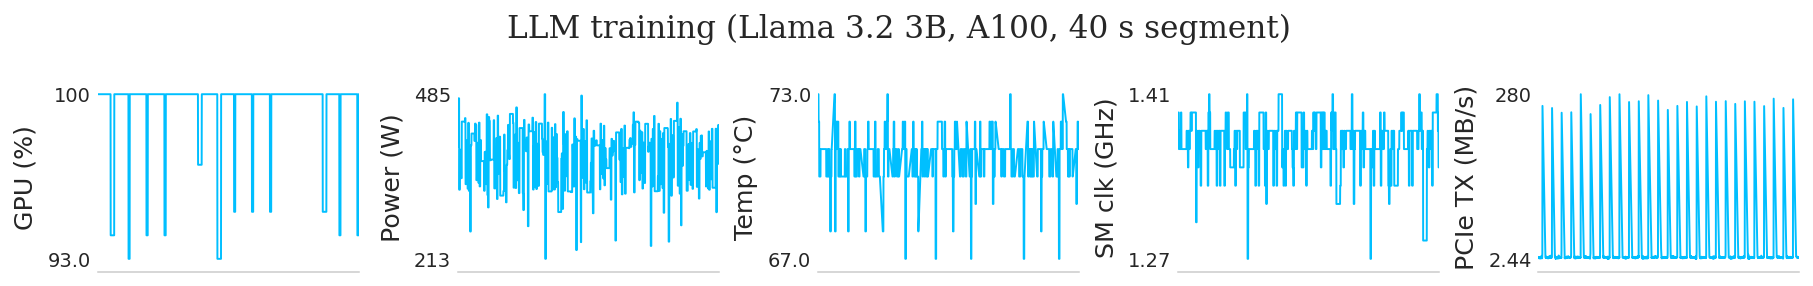

In [21]:
plot_llm_training_ai2027_style(
    all_runs,
    run_name="llm_training",
    title= "LLM training (Llama 3.2 3B, A100, 40 s segment)",
    start_s=SHORT_VIEW_START_S,
    duration_s=40,
    signals=PRIMARY_SIGNALS,
    smooth=False,
    pcie_unit="MB/s",
)

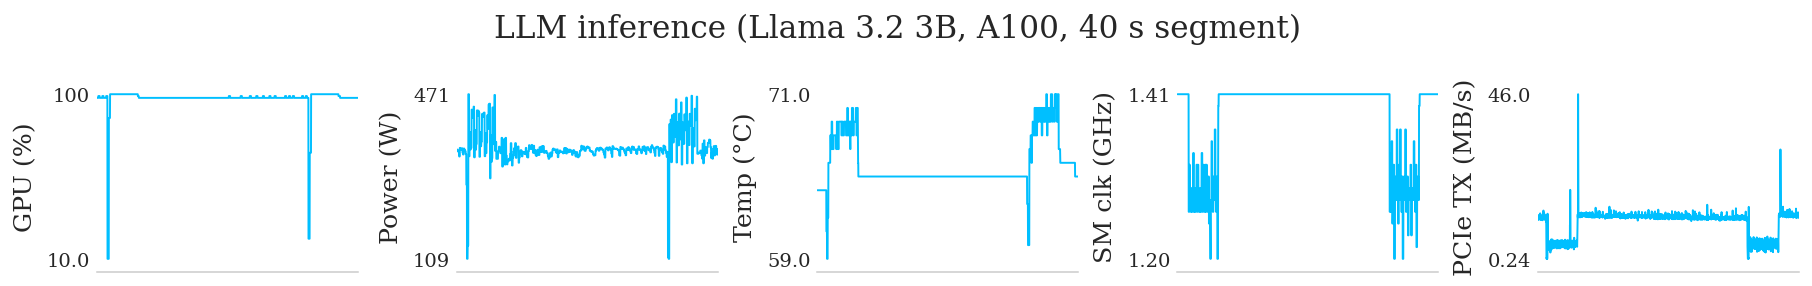

In [22]:
plot_llm_training_ai2027_style(
    all_runs,
    run_name="llm_inference",
    title="LLM inference (Llama 3.2 3B, A100, 40 s segment)",
    start_s=95,
    duration_s=40,
    signals=PRIMARY_SIGNALS,
    smooth=False,
    pcie_unit="MB/s",
)

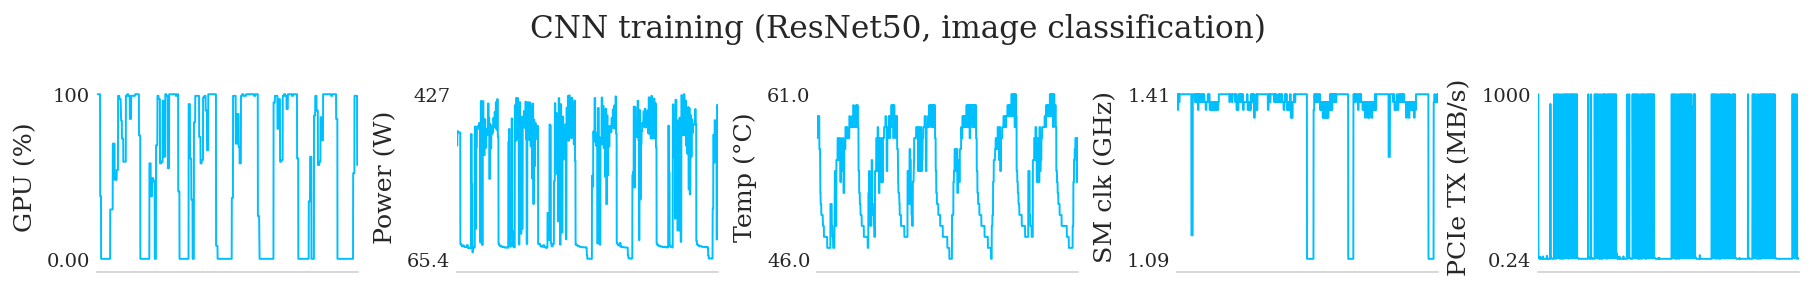

In [23]:
plot_llm_training_ai2027_style(
    all_runs,
    run_name="resnet_training",
    title="CNN training (ResNet50, image classification)",
    start_s=95,
    duration_s=40,
    signals=PRIMARY_SIGNALS,
    smooth=False,
    pcie_unit="MB/s",
)

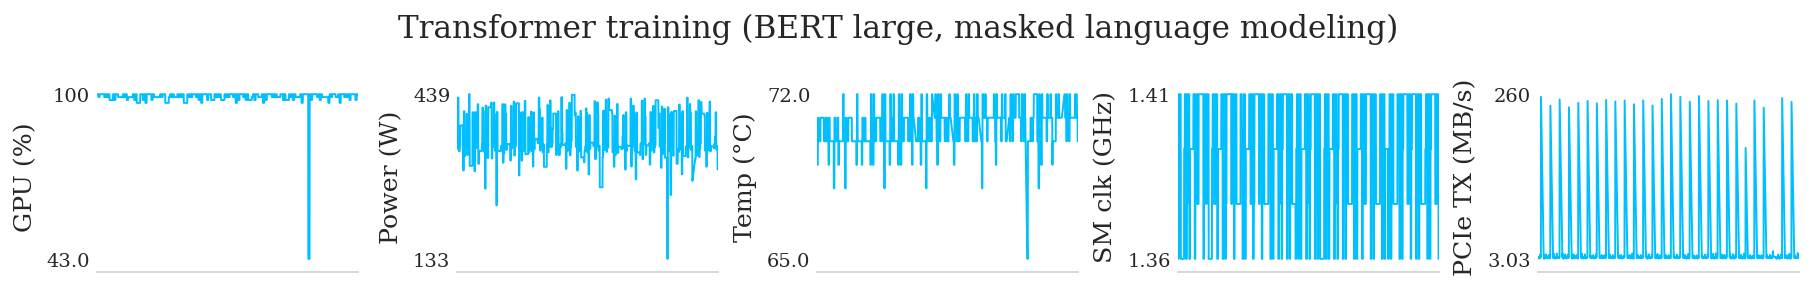

In [24]:
plot_llm_training_ai2027_style(
    all_runs,
    run_name="transformer_non_llm_training",
    title="Transformer training (BERT large, masked language modeling)",
    start_s=95,
    duration_s=40,
    signals=PRIMARY_SIGNALS,
    smooth=False,
    pcie_unit="MB/s",
)

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from typing import Dict, Any, List, Optional

def plot_workload_grid_with_row_titles(
    all_runs: Dict[str, Dict[str, Dict[str, Any]]],
    run_specs: Optional[List[Dict[str, Any]]] = None,
    signals: Optional[List[str]] = None,
    figure_title: str = "Illustrative telemetry patterns across workloads",
    smooth: bool = False,
    smooth_window: int = 7,
    figsize_per_panel: float = 2.45,
    panel_height: float = 1.45,
    title_row_height: float = 0.7,
    line_width: float = 1.0,
    pcie_unit: str = "MB/s",
    save_path: Optional[str] = None,
) -> None:
    """
    One figure with:
    - one title row per workload
    - one plot row per workload
    """

    if signals is None:
        signals = PRIMARY_SIGNALS

    if run_specs is None:
        run_specs = [
            {
                "run_name": "llm_training",
                "start_s": SHORT_VIEW_START_S,
                "duration_s": 40,
                "label": "i. LLM training (Llama 3.2 3B)",
            },
            {
                "run_name": "llm_inference",
                "start_s": 95,
                "duration_s": 40,
                "label": "ii. LLM inference (Llama 3.2 3B)",
            },
            {
                "run_name": "resnet_training",
                "start_s": 95,
                "duration_s": 40,
                "label": "iii. CNN training (ResNet50)",
            },
            {
                "run_name": "transformer_non_llm_training",
                "start_s": 95,
                "duration_s": 40,
                "label": "iv. Transformer training (BERT large MLM)",
            },
        ]

    n_workloads = len(run_specs)
    ncols = len(signals)
    total_rows = 2 * n_workloads

    plt.rcParams.update({
        "font.family": "serif",
        "axes.linewidth": 0.8,
    })

    fig = plt.figure(
        figsize=(figsize_per_panel * ncols, n_workloads * (panel_height + title_row_height))
    )

    height_ratios = []
    for _ in range(n_workloads):
        height_ratios.extend([title_row_height, panel_height])

    gs = GridSpec(
        total_rows,
        ncols,
        figure=fig,
        height_ratios=height_ratios,
        hspace=0.45,
        wspace=0.40,
    )

    custom_labels = {
        "gpu_util": "GPU (%)",
        "power": "Power (W)",
        "temperature": "Temp (°C)",
        "sm_clock": "SM clk (GHz)",
        "pcie_tx": "PCIe TX (MB/s)" if pcie_unit == "MB/s" else "PCIe TX",
    }

    row_colors = [
        "deepskyblue",
        "lightskyblue",
        "skyblue",
        "steelblue",
    ]

    def format_tick(v: float) -> str:
        if abs(v) >= 100:
            return f"{int(round(v))}"
        elif abs(v) >= 10:
            return f"{v:.1f}"
        else:
            return f"{v:.2f}"

    def sci_2line(v: float) -> str:
        s = f"{v:.1e}"
        mantissa, exp = s.split("e")
        return f"{mantissa}\n" + f"e{exp}"

    for row_idx, spec in enumerate(run_specs):
        title_row = 2 * row_idx
        plot_row = title_row + 1
        row_color = row_colors[row_idx % len(row_colors)]

        # title axis spanning all columns
        ax_title = fig.add_subplot(gs[title_row, :])
        ax_title.axis("off")
        ax_title.text(
            0.5, 0.0,
            spec["label"],
            transform=ax_title.transAxes,
            ha="center",
            va="bottom", #123,
            fontsize=14
        )

        run_name = spec["run_name"]
        start_s = spec["start_s"]
        duration_s = spec["duration_s"]
        end_s = start_s + duration_s

        for col_idx, signal_type in enumerate(signals):
            ax = fig.add_subplot(gs[plot_row, col_idx])

            content = all_runs.get(run_name, {}).get(signal_type)

            if content is None:
                ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
                ax.set_xticks([])
                ax.set_yticks([])
                for spine in ax.spines.values():
                    spine.set_visible(False)
                continue

            df = content["df"]
            value_col = content["value_col"]

            view = df[(df["time_s"] >= start_s) & (df["time_s"] <= end_s)].copy()

            if view.empty:
                ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
                ax.set_xticks([])
                ax.set_yticks([])
                for spine in ax.spines.values():
                    spine.set_visible(False)
                continue

            x = view["time_s"].to_numpy() - start_s
            y = view[value_col].to_numpy().astype(float)

            if signal_type == "power" and np.nanmax(y) > 10000:
                y = y / 1000.0

            if signal_type == "sm_clock":
                y = y / 1000.0

            if signal_type == "pcie_tx" and pcie_unit == "MB/s":
                y = y / 1000.0

            if smooth and len(y) >= smooth_window:
                kernel = np.ones(smooth_window) / smooth_window
                y = np.convolve(y, kernel, mode="same")

            ax.plot(
                x, y,
                color=row_color,
                linewidth=line_width,
                solid_capstyle="round"
            )

            ax.set_xlim(0, duration_s)

            y_min = np.nanmin(y)
            y_max = np.nanmax(y)

            if np.isfinite(y_min) and np.isfinite(y_max):
                if y_max > y_min:
                    pad = 0.08 * (y_max - y_min)
                    y_lo = y_min - pad
                    y_hi = y_max + pad
                else:
                    pad = 0.05 * max(abs(y_max), 1.0)
                    y_lo = y_min - pad
                    y_hi = y_max + pad

                ax.set_ylim(y_lo, y_hi)
                ax.set_yticks([y_min, y_max])

                if signal_type == "pcie_tx" and pcie_unit == "scientific":
                    ax.set_yticklabels([sci_2line(y_min), sci_2line(y_max)], fontsize=9)
                else:
                    ax.set_yticklabels([format_tick(y_min), format_tick(y_max)], fontsize=9)

            ax.grid(False)

            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.spines["left"].set_visible(False)
            ax.spines["bottom"].set_linewidth(0.8)

            xticks = np.arange(0, duration_s + 1, 10)
            ax.set_xticks(xticks)
            ax.set_xticklabels([])
            ax.tick_params(axis="x", length=0, width=0.8, pad=2)
            ax.tick_params(axis="y", length=0)

            label = custom_labels.get(
                signal_type,
                SIGNAL_CONFIG.get(signal_type, {}).get("label", signal_type)
            )
            ax.set_ylabel(label, fontsize=12, labelpad=5)

    fig.suptitle(
        figure_title,
        fontsize=18,
        y=0.995
    )

    plt.subplots_adjust(
        left=0.07,
        right=0.995,
        bottom=0.05,
        top=0.95,
    )

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

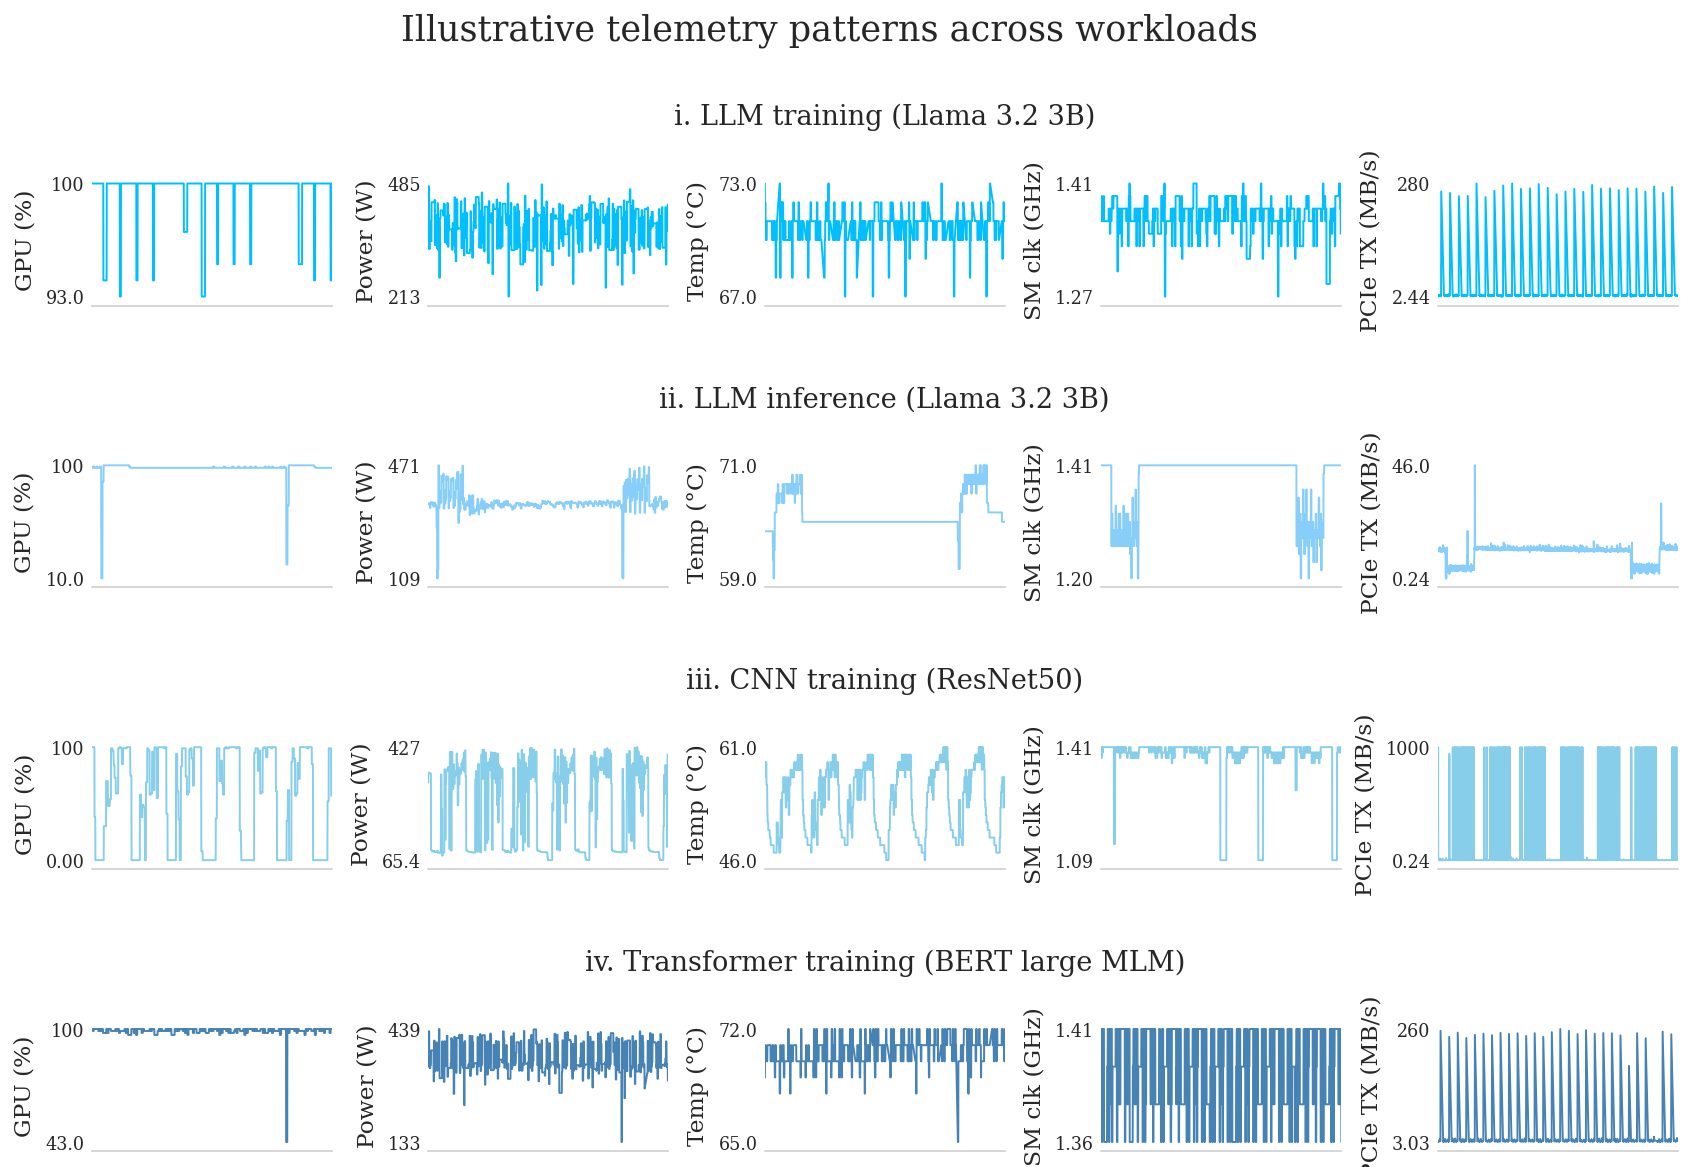

In [26]:
run_specs = [
    {
        "run_name": "llm_training",
        "start_s": SHORT_VIEW_START_S,
        "duration_s": 40,
        "label": "i. LLM training (Llama 3.2 3B)",
    },
    {
        "run_name": "llm_inference",
        "start_s": 95,
        "duration_s": 40,
        "label": "ii. LLM inference (Llama 3.2 3B)",
    },
    {
        "run_name": "resnet_training",
        "start_s": 95,
        "duration_s": 40,
        "label": "iii. CNN training (ResNet50)",
    },
    {
        "run_name": "transformer_non_llm_training",
        "start_s": 95,
        "duration_s": 40,
        "label": "iv. Transformer training (BERT large MLM)",
    },
]

plot_workload_grid_with_row_titles(
    all_runs=all_runs,
    run_specs=run_specs,
    signals=PRIMARY_SIGNALS,
    figure_title="Illustrative telemetry patterns across workloads",
    smooth=False,
    pcie_unit="MB/s",
    save_path=None,
)

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, Any, Optional

def plot_power_window(
    all_runs: Dict[str, Dict[str, Dict[str, Any]]],
    run_name: str,
    start_s: float,
    duration_s: float = 2.0,
    title: Optional[str] = None,
    smooth: bool = False,
    smooth_window: int = 5,
    figsize: tuple = (4.6, 2.2),
    line_width: float = 1.2,
    color: str = "deepskyblue",
    save_path: Optional[str] = None,
) -> None:
    """
    Plot a configurable time window of power telemetry for one run.
    """

    content = all_runs.get(run_name, {}).get("power")
    if content is None:
        raise ValueError(f"No power data found for run_name='{run_name}'")

    df = content["df"]
    value_col = content["value_col"]

    end_s = start_s + duration_s
    view = df[(df["time_s"] >= start_s) & (df["time_s"] <= end_s)].copy()

    if view.empty:
        raise ValueError(
            f"No data found for run_name='{run_name}' in window [{start_s}, {end_s}]"
        )

    x = view["time_s"].to_numpy() - start_s
    y = view[value_col].to_numpy().astype(float)

    # mW -> W
    if np.nanmax(y) > 10000:
        y = y / 1000.0

    # optional smoothing
    if smooth and len(y) >= smooth_window:
        kernel = np.ones(smooth_window) / smooth_window
        y = np.convolve(y, kernel, mode="same")

    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(
        x, y,
        color=color,
        linewidth=line_width,
        solid_capstyle="round"
    )

    ax.set_xlim(0, duration_s)

    y_min = np.nanmin(y)
    y_max = np.nanmax(y)

    if np.isfinite(y_min) and np.isfinite(y_max):
        if y_max > y_min:
            pad = 0.06 * (y_max - y_min)
        else:
            pad = 0.05 * max(abs(y_max), 1.0)
        ax.set_ylim(y_min - pad, y_max + pad)

    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_linewidth(0.8)

    ax.tick_params(axis="x", length=0)
    ax.tick_params(axis="y", length=0)

    ax.set_ylabel("Power (W)", fontsize=11)

    n_ticks = 3 if duration_s <= 2.5 else 4
    xticks = []
    ax.set_xticks(xticks)
    ax.set_xticks([])
    ax.set_xticklabels([f"{t:.1f}" for t in xticks], fontsize=9)

    ax.set_yticks([y_min, y_max])

    def fmt(v: float) -> str:
        if abs(v) >= 100:
            return f"{int(round(v))}"
        elif abs(v) >= 10:
            return f"{v:.1f}"
        else:
            return f"{v:.2f}"

    ax.set_yticklabels([fmt(y_min), fmt(y_max)], fontsize=9)


    if title is None:
        title = f"{duration_s:.1f}-second window of power telemetry"

    ax.set_title(title, fontsize=11, pad=8)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

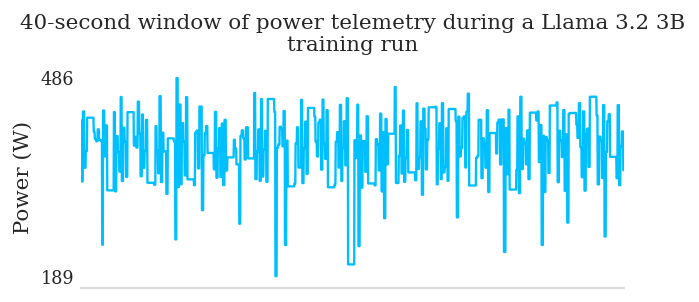

In [28]:
plot_power_window(
    all_runs=all_runs,
    run_name="llm_training",
    start_s=120.0,
    duration_s=40.0,
    title="40-second window of power telemetry during a Llama 3.2 3B\ntraining run",
    smooth=False,
)

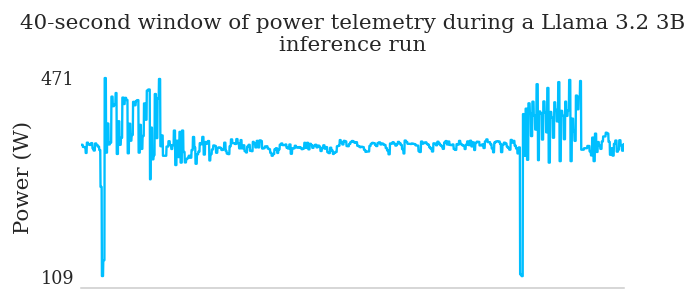

In [29]:
plot_power_window(
    all_runs=all_runs,
    run_name="llm_inference",
    start_s=95.0,
    duration_s=40,
    title="40-second window of power telemetry during a Llama 3.2 3B\ninference run",
    smooth=False,
)

In [30]:
def plot_power_window_multi(
    all_runs: Dict[str, Dict[str, Dict[str, Any]]],
    runs: Dict[str, Dict[str, Any]],
    start_s: float,
    duration_s: float = 2.0,
    title: Optional[str] = None,
    smooth: bool = False,
    smooth_window: int = 5,
    figsize: tuple = (4.6, 2.7),
    save_path: Optional[str] = None,
) -> None:

    fig, ax = plt.subplots(figsize=figsize)

    for run_name, style in runs.items():
        content = all_runs.get(run_name, {}).get("power")
        if content is None:
            raise ValueError(f"No power data for '{run_name}'")

        df = content["df"]
        value_col = content["value_col"]

        end_s = start_s + duration_s
        view = df[(df["time_s"] >= start_s) & (df["time_s"] <= end_s)].copy()

        x = view["time_s"].to_numpy() - start_s
        y = view[value_col].to_numpy().astype(float)

        if np.nanmax(y) > 10000:
            y = y / 1000.0

        if smooth and len(y) >= smooth_window:
            kernel = np.ones(smooth_window) / smooth_window
            y = np.convolve(y, kernel, mode="same")

        ax.plot(
            x, y,
            color=style.get("color", "deepskyblue"),
            linewidth=style.get("linewidth", 1.2),
            alpha=style.get("alpha", 1.0),
            linestyle=style.get("linestyle", "-"),
            label=style.get("label", run_name),
            solid_capstyle="round"
        )

    ax.set_xlim(0, duration_s)
    ax.set_xticks([])
    ax.set_xticklabels([])

    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_linewidth(0.8)

    ax.tick_params(axis="y", length=0)

    ax.set_ylabel("Power (W)", fontsize=11)


    if title is None:
        title = f"{duration_s:.1f}-second window of power telemetry"

    ax.set_title(title, fontsize=11, pad=8)


    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.05),
        ncol=len(runs),
        frameon=False,
        fontsize=9,
        handlelength=2.5
    )

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

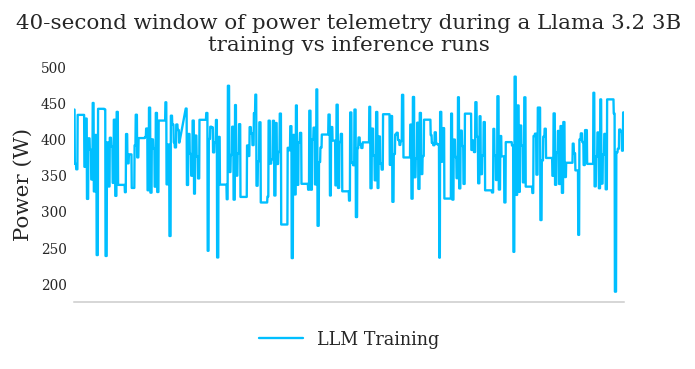

In [31]:
plot_power_window_multi(
    all_runs=all_runs,
    runs={
        "llm_training": {
            "color": "gray",
            "alpha": 1,
            "linestyle": "-",
            "label": "LLM Training"
        },
        "llm_training": {
            "color": "deepskyblue",
            "alpha": 1,
            "linestyle": "-",
            "label": "LLM Training"
        },

    },
    start_s=95.0,
    duration_s=40,
    title="40-second window of power telemetry during a Llama 3.2 3B\ntraining vs inference runs"
)

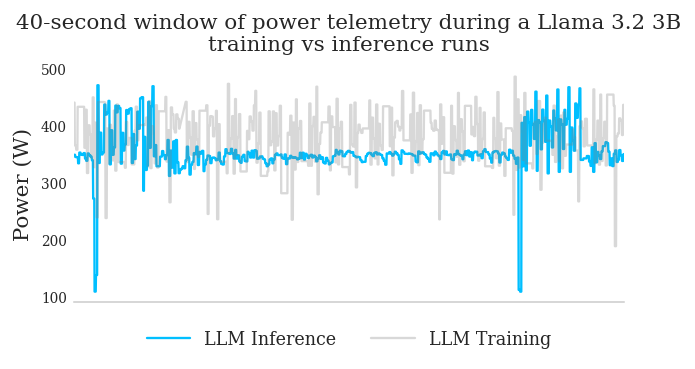

In [32]:
plot_power_window_multi(
    all_runs=all_runs,
    runs={
        "llm_inference": {
            "color": "deepskyblue",
            "alpha": 1.0,
            "linestyle": "-",
            "label": "LLM Inference"
        },
        "llm_training": {
            "color": "gray",
            "alpha": 0.3,
            "linestyle": "-",
            "label": "LLM Training"
        },

    },
    start_s=95.0,
    duration_s=40,
    title="40-second window of power telemetry during a Llama 3.2 3B\ntraining vs inference runs"
)

In [33]:
run_specs

[{'run_name': 'llm_training',
  'start_s': 300.0,
  'duration_s': 40,
  'label': 'i. LLM training (Llama 3.2 3B)'},
 {'run_name': 'llm_inference',
  'start_s': 95,
  'duration_s': 40,
  'label': 'ii. LLM inference (Llama 3.2 3B)'},
 {'run_name': 'resnet_training',
  'start_s': 95,
  'duration_s': 40,
  'label': 'iii. CNN training (ResNet50)'},
 {'run_name': 'transformer_non_llm_training',
  'start_s': 95,
  'duration_s': 40,
  'label': 'iv. Transformer training (BERT large MLM)'}]

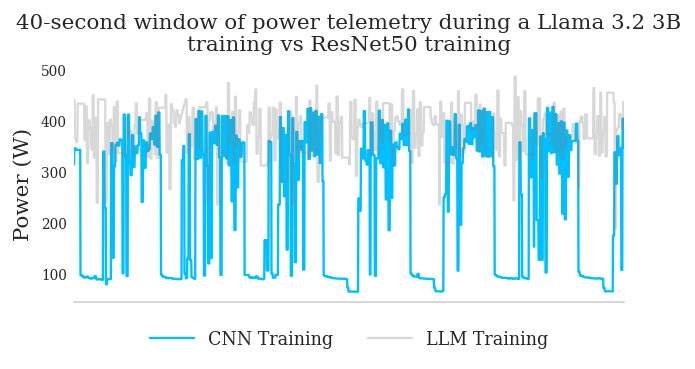

In [34]:
plot_power_window_multi(
    all_runs=all_runs,
    runs= {
        "resnet_training": {
            "color": "deepskyblue",
            "alpha": 1.0,
            "linestyle": "-",
            "label": "CNN Training"
        },

        "llm_training": {
            "color": "gray",
            "alpha": 0.3,
            "linestyle": "-",
            "label": "LLM Training"
        },
    },
    start_s=95.0,
    duration_s=40,
    title="40-second window of power telemetry during a Llama 3.2 3B\ntraining vs ResNet50 training"
)

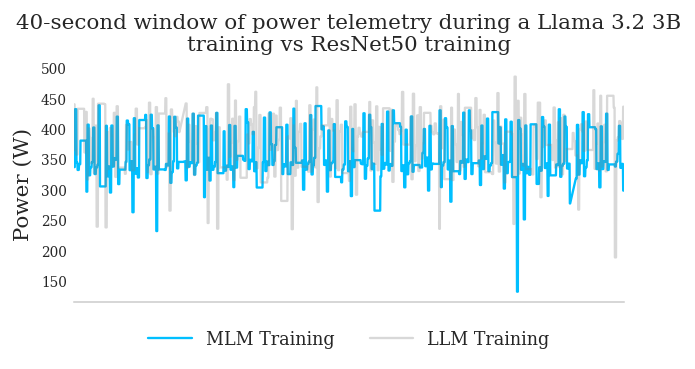

In [35]:
plot_power_window_multi(
    all_runs=all_runs,
    runs= {
        "transformer_non_llm_training": {
            "color": "deepskyblue",
            "alpha": 1.0,
            "linestyle": "-",
            "label": "MLM Training"
        },

        "llm_training": {
            "color": "gray",
            "alpha": 0.3,
            "linestyle": "-",
            "label": "LLM Training"
        },
    },
    start_s=95.0,
    duration_s=40,
    title="40-second window of power telemetry during a Llama 3.2 3B\ntraining vs ResNet50 training"
)

## **Common-grid resampling**

In [79]:
# =============================================================================
# Common-grid resampling
# =============================================================================

def resample_single_signal(
    df: pd.DataFrame,
    value_col: str,
    target_hz: float,
    start_s: float,
    end_s: float,
) -> pd.DataFrame:
    """
    Resample a single signal onto a common uniform grid.
    No extrapolation is used outside the available time range.
    """
    work = df.sort_values("time_s").drop_duplicates(subset=["time_s"]).copy()

    x = work["time_s"].to_numpy(dtype=float)
    y = work[value_col].to_numpy(dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2 or end_s <= start_s:
        return pd.DataFrame(columns=["time_s", "value"])

    step = 1.0 / target_hz
    grid = np.arange(start_s, end_s + 0.5 * step, step, dtype=float)

    interp = interp1d(
        x,
        y,
        kind="linear",
        bounds_error=False,
        fill_value=np.nan,
        assume_sorted=True,
    )
    y_grid = interp(grid)

    out = pd.DataFrame({
        "time_s": grid,
        "value": y_grid,
    })

    out = out.dropna().reset_index(drop=True)
    return out


def build_common_resampled_run(
    run_data: Dict[str, Dict[str, Any]],
    run_name: str,
    target_hz: float = TARGET_RESAMPLE_HZ,
    signals: List[str] = PRIMARY_SIGNALS,
) -> pd.DataFrame:
    """
    Build a common-grid multivariate dataframe for one workload.
    All signals are restricted to the shared valid time interval.
    """
    available_signals = [s for s in signals if s in run_data]
    if len(available_signals) != len(signals):
        missing = sorted(set(signals) - set(available_signals))
        raise ValueError(f"{run_name}: missing required signals: {missing}")

    common_end = min(
        float(run_data[s]["df"]["time_s"].max())
        for s in signals
    )

    common_start = 0.0
    if common_end <= common_start:
        raise ValueError(f"{run_name}: invalid common time interval")

    merged = None

    for signal_type in signals:
        content = run_data[signal_type]
        df = content["df"]
        value_col = content["value_col"]

        res = resample_single_signal(
            df=df,
            value_col=value_col,
            target_hz=target_hz,
            start_s=common_start,
            end_s=common_end,
        ).rename(columns={"value": signal_type})

        if merged is None:
            merged = res
        else:
            merged = pd.merge(merged, res, on="time_s", how="inner")

    merged["run_name"] = run_name
    merged["run_display_name"] = RUN_DISPLAY_NAMES[run_name]

    cols = ["run_name", "run_display_name", "time_s"] + signals
    return merged[cols].reset_index(drop=True)


resampled_runs = {}

for run_name in WORKLOAD_ORDER:
    resampled_runs[run_name] = build_common_resampled_run(
        run_data=all_runs[run_name],
        run_name=run_name,
        target_hz=TARGET_RESAMPLE_HZ,
        signals=PRIMARY_SIGNALS,
    )

for run_name in WORKLOAD_ORDER:
    print(run_name, resampled_runs[run_name].shape)

display(resampled_runs["llm_training"].head())

llm_training (88037, 8)
transformer_non_llm_training (71869, 8)
resnet_training (71941, 8)
llm_inference (71881, 8)


,run_name,run_display_name,time_s,gpu_util,power,temperature,sm_clock,pcie_tx
0,llm_training,LLM Training,0.00,94.0,393023.000000,72.000000,1395.000000,5078.000000
1,llm_training,LLM Training,0.05,100.0,431749.000000,72.000000,1395.000000,4501.184390
2,llm_training,LLM Training,0.10,100.0,431749.000000,71.116109,1395.000000,4756.669469
3,llm_training,LLM Training,0.15,100.0,385606.000000,71.000000,1350.000000,4668.926387
4,llm_training,LLM Training,0.20,100.0,383490.777519,71.000000,1368.608995,4880.420428


In [37]:
# =============================================================================
# Window dataset construction
# =============================================================================

def binary_label_from_run_name(run_name: str) -> str:
    """
    Map workload names to the binary target.
    """
    if run_name == "llm_training":
        return "LLM Training"
    return "Not LLM Training"


def build_window_dataset_binary(
    resampled_runs: Dict[str, pd.DataFrame],
    signals: List[str] = PRIMARY_SIGNALS,
    window_size_s: float = WINDOW_SIZE_S,
    window_step_s: float = WINDOW_STEP_S,
    target_hz: float = TARGET_RESAMPLE_HZ,
) -> Tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    """
    Build a multivariate equal-length window dataset in aeon format:
        X.shape = (n_cases, n_channels, n_timepoints)

    Labels are binary:
        - LLM Training
        - Not LLM Training
    """
    window_len = int(round(window_size_s * target_hz))
    step_len = int(round(window_step_s * target_hz))

    X_list = []
    y_list = []
    meta_rows = []

    for run_name in WORKLOAD_ORDER:
        df = resampled_runs[run_name].copy()
        values = df[signals].to_numpy(dtype=np.float32)
        times = df["time_s"].to_numpy(dtype=float)

        n = len(df)
        if n < window_len:
            continue

        starts = np.arange(0, n - window_len + 1, step_len, dtype=int)

        for i, start_idx in enumerate(starts):
            end_idx = start_idx + window_len
            window = values[start_idx:end_idx]   # shape: (T, C)
            window = window.T                    # shape: (C, T)

            X_list.append(window)
            y_list.append(binary_label_from_run_name(run_name))

            meta_rows.append({
                "run_name": run_name,
                "run_display_name": RUN_DISPLAY_NAMES[run_name],
                "binary_label": binary_label_from_run_name(run_name),
                "window_id_within_run": i,
                "start_idx": int(start_idx),
                "end_idx": int(end_idx - 1),
                "start_s": float(times[start_idx]),
                "end_s": float(times[end_idx - 1]),
            })

    X = np.stack(X_list, axis=0)
    y = np.asarray(y_list)
    meta_df = pd.DataFrame(meta_rows)

    return X, y, meta_df


X, y, windows_meta_df = build_window_dataset_binary(
    resampled_runs=resampled_runs,
    signals=PRIMARY_SIGNALS,
    window_size_s=WINDOW_SIZE_S,
    window_step_s=WINDOW_STEP_S,
    target_hz=TARGET_RESAMPLE_HZ,
)

print("X shape:", X.shape)
print("y shape:", y.shape)
display(windows_meta_df.head())
display(pd.crosstab(windows_meta_df["run_display_name"], windows_meta_df["binary_label"]))


X shape: (377, 5, 800)
y shape: (377,)


,run_name,run_display_name,binary_label,window_id_within_run,start_idx,end_idx,start_s,end_s
0,llm_training,LLM Training,LLM Training,0,0,799,0.0,39.95
1,llm_training,LLM Training,LLM Training,1,800,1599,40.0,79.95
2,llm_training,LLM Training,LLM Training,2,1600,2399,80.0,119.95
3,llm_training,LLM Training,LLM Training,3,2400,3199,120.0,159.95
4,llm_training,LLM Training,LLM Training,4,3200,3999,160.0,199.95


binary_label,LLM Training,Not LLM Training
run_display_name,,
CNN Training,0,89
LLM Inference,0,89
LLM Training,110,0
MLM Training,0,89


In [38]:

# =============================================================================
# Blocked temporal split with a gap
# =============================================================================

def make_blocked_temporal_split_with_gap(
    meta_df: pd.DataFrame,
    train_fraction: float = 0.6,
    gap_fraction: float = 0.1,
) -> pd.DataFrame:
    """
    Temporal blocked split within each run:
    - early windows -> train
    - middle windows -> discarded gap
    - later windows -> test

    This is a preliminary within-run temporal generalization setup.
    The gap reduces near-neighbor leakage between train and test.
    """
    meta_df = meta_df.copy()
    meta_df["split"] = "discard"

    for run_name in WORKLOAD_ORDER:
        idx = meta_df.index[meta_df["run_name"] == run_name].to_numpy()
        idx_sorted = idx[np.argsort(meta_df.loc[idx, "start_s"].to_numpy())]

        n = len(idx_sorted)
        if n < 3:
            raise ValueError(f"Not enough windows for run: {run_name}")

        n_train = int(np.floor(train_fraction * n))
        n_gap = int(np.floor(gap_fraction * n))

        train_end = n_train
        gap_end = min(n, train_end + n_gap)

        train_idx = idx_sorted[:train_end]
        test_idx = idx_sorted[gap_end:]

        meta_df.loc[train_idx, "split"] = "train"
        meta_df.loc[test_idx, "split"] = "test"

    return meta_df


windows_meta_df = make_blocked_temporal_split_with_gap(
    windows_meta_df,
    train_fraction=0.6,
    gap_fraction=0.1,
)

display(windows_meta_df["split"].value_counts())
display(pd.crosstab(windows_meta_df["run_display_name"], windows_meta_df["split"]))
display(pd.crosstab(windows_meta_df["binary_label"], windows_meta_df["split"]))



,count
split,
train,225
test,117
discard,35


split,discard,test,train
run_display_name,,,
CNN Training,8,28,53
LLM Inference,8,28,53
LLM Training,11,33,66
MLM Training,8,28,53


split,discard,test,train
binary_label,,,
LLM Training,11,33,66
Not LLM Training,24,84,159


In [39]:
# =============================================================================
# Final arrays
# =============================================================================

train_mask = windows_meta_df["split"].to_numpy() == "train"
test_mask = windows_meta_df["split"].to_numpy() == "test"

X_train = X[train_mask]
y_train = y[train_mask]

X_test = X[test_mask]
y_test = y[test_mask]

train_meta_df = windows_meta_df.loc[train_mask].reset_index(drop=True)
test_meta_df = windows_meta_df.loc[test_mask].reset_index(drop=True)

print("Train:", X_train.shape, y_train.shape)
print("Test: ", X_test.shape, y_test.shape)

display(pd.crosstab(train_meta_df["run_display_name"], train_meta_df["binary_label"]))
display(pd.crosstab(test_meta_df["run_display_name"], test_meta_df["binary_label"]))




Train: (225, 5, 800) (225,)
Test:  (117, 5, 800) (117,)


binary_label,LLM Training,Not LLM Training
run_display_name,,
CNN Training,0,53
LLM Inference,0,53
LLM Training,66,0
MLM Training,0,53


binary_label,LLM Training,Not LLM Training
run_display_name,,
CNN Training,0,28
LLM Inference,0,28
LLM Training,33,0
MLM Training,0,28


## **Spectral comparison across workloads**

In [80]:
for run_name in WORKLOAD_ORDER:
    df = resampled_runs[run_name]
    n = len(df)
    window_len = int(round(WINDOW_SIZE_S * TARGET_RESAMPLE_HZ))
    step_len = int(round(WINDOW_STEP_S * TARGET_RESAMPLE_HZ))
    n_windows = max(0, (n - window_len) // step_len + 1)

    print(run_name)
    print("  n_resampled_points:", n)
    print("  duration_s:", df["time_s"].max())
    print("  window_len_points:", window_len)
    print("  step_len_points:", step_len)
    print("  n_windows:", n_windows)
    print()

llm_training
  n_resampled_points: 88037
  duration_s: 4401.8
  window_len_points: 800
  step_len_points: 800
  n_windows: 110

transformer_non_llm_training
  n_resampled_points: 71869
  duration_s: 3593.4
  window_len_points: 800
  step_len_points: 800
  n_windows: 89

resnet_training
  n_resampled_points: 71941
  duration_s: 3597.0
  window_len_points: 800
  step_len_points: 800
  n_windows: 89

llm_inference
  n_resampled_points: 71881
  duration_s: 3594.0
  window_len_points: 800
  step_len_points: 800
  n_windows: 89



In [44]:
# =============================================================================
# PSD helpers
# =============================================================================

def compute_single_window_psd(
    signal: np.ndarray,
    fs: float,
    nperseg: Optional[int] = None,
) -> Tuple[np.ndarray, np.ndarray]:
    x = np.asarray(signal, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) < 8:
        return np.array([]), np.array([])

    x = x - np.mean(x)

    if nperseg is None:
        nperseg = min(len(x), max(32, len(x) // 4))

    if nperseg < 8:
        return np.array([]), np.array([])

    freqs, pxx = welch(
        x,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=nperseg // 2,
        detrend="constant",
        scaling="density",
    )
    return freqs, pxx


def get_resampled_signal_series(
    resampled_runs: Dict[str, pd.DataFrame],
    run_name: str,
    signal_type: str,
) -> Tuple[np.ndarray, np.ndarray]:
    df = resampled_runs[run_name].copy()
    return (
        df["time_s"].to_numpy(dtype=float),
        df[signal_type].to_numpy(dtype=float),
    )


def extract_window_from_resampled_signal(
    resampled_runs: Dict[str, pd.DataFrame],
    run_name: str,
    signal_type: str,
    start_s: float,
    duration_s: float,
) -> Tuple[np.ndarray, np.ndarray]:
    df = resampled_runs[run_name].copy()
    end_s = start_s + duration_s
    view = df[(df["time_s"] >= start_s) & (df["time_s"] <= end_s)].copy()

    if view.empty:
        return np.array([]), np.array([])

    x = view["time_s"].to_numpy(dtype=float)
    x = x - x[0]
    y = view[signal_type].to_numpy(dtype=float)
    return x, y


def extract_multiple_windows_from_resampled_signal(
    resampled_runs: Dict[str, pd.DataFrame],
    run_name: str,
    signal_type: str,
    window_size_s: float,
    start_times_s: List[float],
) -> List[Tuple[np.ndarray, np.ndarray]]:
    out = []
    for start_s in start_times_s:
        x, y = extract_window_from_resampled_signal(
            resampled_runs=resampled_runs,
            run_name=run_name,
            signal_type=signal_type,
            start_s=start_s,
            duration_s=window_size_s,
        )
        out.append((x, y))
    return out

def _clean_editorial_axes(ax, hide_left_spine: bool = True):
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if hide_left_spine:
        ax.spines["left"].set_visible(False)
        ax.tick_params(axis="y", length=0)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.tick_params(axis="both", labelsize=7, width=0.7)

In [52]:
# =============================================================================
# Example raw windows, per-window PSDs, and mean PSD for one signal
# Refined editorial layout
# =============================================================================

def plot_raw_windows_and_mean_psd_for_one_signal(
    resampled_runs: Dict[str, pd.DataFrame],
    run_name: str,
    signal_type: str = "power",
    target_hz: float = TARGET_RESAMPLE_HZ,
    window_size_s: float = 30.0,
    start_times_s: Optional[List[float]] = None,
    long_view_duration_s: float = 150.0,
    title: str = "From raw signal to frequency profile",
    base_long_color: str = "gray",
    window_colors: Optional[List[str]] = None,
    psd_color: str = "hotpink",
    save_path: Optional[str] = None,
) -> None:
    """
    Layout:
        row 1: centered long segment
        row 2: three windows in time domain
        row 3: three PSDs, one for each window
        row 4: centered mean PSD across windows
    """
    if start_times_s is None:
        start_times_s = [0.0, 15.0, 30.0]

    if len(start_times_s) != 3:
        raise ValueError("start_times_s must contain exactly 3 start times.")

    if window_colors is None:
        window_colors = ["deepskyblue", "cyan", "c"]

    df = resampled_runs[run_name].copy()

    if signal_type not in df.columns:
        raise ValueError(f"{signal_type} not found in resampled run dataframe.")

    # -------------------------------------------------------------------------
    # Long-view data
    # -------------------------------------------------------------------------
    long_end_s = min(long_view_duration_s, float(df["time_s"].max()))
    long_view = df[(df["time_s"] >= 0.0) & (df["time_s"] <= long_end_s)].copy()

    if long_view.empty:
        raise ValueError("Long-view slice is empty.")

    x_long = long_view["time_s"].to_numpy(dtype=float)
    y_long = long_view[signal_type].to_numpy(dtype=float)

    if signal_type == "power" and np.nanmax(y_long) > 10000:
        y_long = y_long / 1000.0

    # -------------------------------------------------------------------------
    # Window data
    # -------------------------------------------------------------------------
    raw_windows = extract_multiple_windows_from_resampled_signal(
        resampled_runs=resampled_runs,
        run_name=run_name,
        signal_type=signal_type,
        window_size_s=window_size_s,
        start_times_s=start_times_s,
    )

    # -------------------------------------------------------------------------
    # Figure / layout
    # -------------------------------------------------------------------------
    plt.rcParams.update({
        "font.family": "serif",
        "axes.linewidth": 0.61,
    })

    fig = plt.figure(figsize=(5.1, 6.1))
    gs = fig.add_gridspec(
        4, 8,
        height_ratios=[1.05, 0.6, 0.6, 1.0],
        width_ratios=[0.35, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.35],
    )

    # top a bit wider than before
    ax_long = fig.add_subplot(gs[0, 2:6])
    ax_long.set_title("Raw signal", fontsize=9, pad=4)

    raw_axes = [
        fig.add_subplot(gs[1, 1:3]),
        fig.add_subplot(gs[1, 3:5]),
        fig.add_subplot(gs[1, 5:7]),
    ]

    psd_axes = [
        fig.add_subplot(gs[2, 1:3]),
        fig.add_subplot(gs[2, 3:5]),
        fig.add_subplot(gs[2, 5:7]),
    ]

    ax_psd_mean = fig.add_subplot(gs[3, 2:6])

    # -------------------------------------------------------------------------
    # Row 1: long signal
    # -------------------------------------------------------------------------
    ax_long.plot(
        x_long,
        y_long,
        color="gray",
        linewidth=0.31,
        zorder=1,
        alpha=0.9,
    )

    for start_s, color in zip(start_times_s, window_colors):
        end_s = start_s + window_size_s
        mask = (x_long >= start_s) & (x_long <= end_s)
        if np.any(mask):
            ax_long.plot(
                x_long[mask],
                y_long[mask],
                color=color,
                linewidth=0.61,
                zorder=3,
            )
            ax_long.axvspan(
                start_s,
                end_s,
                color=color,
                alpha=0.07,
                linewidth=0,
                zorder=0,
            )

    ax_long.set_xlabel("Time (s)", fontsize=7, labelpad=2)
    ax_long.set_ylabel("Power (W)", fontsize=7, labelpad=4)
    ax_psd_mean.set_title("From raw signal to frequency profile", fontsize=10, pad=6)


    ax_long.grid(False)
    ax_long.spines["top"].set_visible(False)
    ax_long.spines["right"].set_visible(False)
    ax_long.spines["left"].set_visible(False)
    ax_long.spines["bottom"].set_linewidth(0.61)
    ax_long.tick_params(axis="x", labelsize=7, length=0, width=0.7)
    ax_long.tick_params(axis="y", length=0, width=0.7)
    ax_long.set_xticklabels([])
    ax_long.set_yticklabels([])

    # -------------------------------------------------------------------------
    # Row 2: windows in time domain
    # Row 3: PSD of each window
    # -------------------------------------------------------------------------
    psd_list = []
    freqs_ref = None

    for i, ((ax_raw, ax_psd, (x, y), color)) in enumerate(
        zip(raw_axes, psd_axes, raw_windows, window_colors)
    ):
        if len(x) == 0:
            for ax in [ax_raw, ax_psd]:
                ax.text(
                    0.5, 0.5, "No data",
                    ha="center", va="center",
                    transform=ax.transAxes,
                    fontsize=7,
                )
                ax.set_xticks([])
                ax.set_yticks([])
                for spine in ax.spines.values():
                    spine.set_visible(False)
            continue

        y_plot = y.copy()
        if signal_type == "power" and np.nanmax(y_plot) > 10000:
            y_plot = y_plot / 1000.0

        # --- raw window ---
        ax_raw.plot(x, y_plot, color=color, linewidth=0.61)
        ax_raw.set_title(f"Window {i+1}", fontsize=10, pad=4)
        ax_raw.set_xlabel("Time (s)", fontsize=7, labelpad=2)

        if i == 0:
            ax_raw.set_ylabel("Power (W)", fontsize=7, labelpad=4)
        else:
            ax_raw.set_ylabel("")

        ax_raw.grid(False)
        ax_raw.spines["top"].set_visible(False)
        ax_raw.spines["right"].set_visible(False)
        ax_raw.spines["left"].set_visible(False)
        ax_raw.spines["bottom"].set_linewidth(0.61)
        ax_raw.tick_params(axis="x", labelsize=7, length=0, width=0.7)
        ax_raw.tick_params(axis="y", length=0, width=0.7)
        ax_raw.set_xticklabels([])
        ax_raw.set_yticklabels([])

        # --- PSD of that window ---
        freqs, pxx = compute_single_window_psd(y_plot, fs=target_hz)

        if len(freqs) > 0 and len(pxx) > 0:
            valid = (freqs > 0) & (pxx > 0) & np.isfinite(pxx)
            ax_psd.plot(
                freqs[valid],
                pxx[valid],
                color=psd_color,
                linewidth=0.8,
            )
            ax_psd.set_xscale("log")
            ax_psd.set_yscale("log")

            if freqs_ref is None:
                freqs_ref = freqs
                psd_list.append(pxx)
            elif len(freqs) == len(freqs_ref) and np.allclose(freqs, freqs_ref):
                psd_list.append(pxx)

        ax_psd.set_title(f"Window {i+1} (PSD)", fontsize=9, pad=3)
        ax_psd.set_xlabel("Frequency (Hz)", fontsize=7, labelpad=2)

        if i == 0:
            ax_psd.set_ylabel("PSD", fontsize=7, labelpad=3)
        else:
            ax_psd.set_ylabel("")

        ax_psd.grid(False)
        ax_psd.spines["top"].set_visible(False)
        ax_psd.spines["right"].set_visible(False)
        ax_psd.spines["left"].set_visible(False)
        ax_psd.spines["bottom"].set_linewidth(0.61)
        ax_psd.tick_params(axis="x", labelsize=7, length=3, width=0.7)
        ax_psd.tick_params(axis="y", length=0, width=0.7)
        ax_psd.set_yticklabels([])

    # -------------------------------------------------------------------------
    # Row 4: mean PSD centered
    # -------------------------------------------------------------------------
    if freqs_ref is not None and len(psd_list) > 0:
        psd_arr = np.vstack(psd_list)
        valid_global = freqs_ref > 0

        for row in psd_arr:
            valid = valid_global & (row > 0) & np.isfinite(row)
            ax_psd_mean.plot(
                freqs_ref[valid],
                row[valid],
                color=psd_color,
                linewidth=0.61,
                alpha=0.4,
            )

        mean_psd = np.nanmean(psd_arr, axis=0)
        valid_mean = valid_global & (mean_psd > 0) & np.isfinite(mean_psd)
        ax_psd_mean.plot(
            freqs_ref[valid_mean],
            mean_psd[valid_mean],
            color=psd_color,
            linewidth=1.1,
            alpha=1.0,
        )

        ax_psd_mean.set_xscale("log")
        ax_psd_mean.set_yscale("log")

    ax_psd_mean.set_title("Mean PSD across windows", fontsize=10, pad=6)
    ax_psd_mean.set_xlabel("Frequency (Hz)", fontsize=7, labelpad=2)
    ax_psd_mean.set_ylabel("PSD", fontsize=7, labelpad=3)

    ax_psd_mean.grid(False)
    ax_psd_mean.spines["top"].set_visible(False)
    ax_psd_mean.spines["right"].set_visible(False)
    ax_psd_mean.spines["left"].set_visible(False)
    ax_psd_mean.spines["bottom"].set_linewidth(0.8)
    ax_psd_mean.tick_params(axis="x", labelsize=7, length=3, width=0.7)
    ax_psd_mean.tick_params(axis="y", labelsize=7, length=0, width=0.7)

    fig.suptitle(title, fontsize=10, y=0.985)

    plt.subplots_adjust(
        left=0.07,
        right=0.98,
        top=0.92,
        bottom=0.07,
        hspace=1.15,   # more vertical space overall
        wspace=0.95,
    )

    # extra separation before the bottom plot
    raw_bottom = min(ax.get_position().y0 for ax in psd_axes)
    mean_top = ax_psd_mean.get_position().y1

    if mean_top > raw_bottom - 0.06:
        shift = 0.05
        pos = ax_psd_mean.get_position()
        ax_psd_mean.set_position([pos.x0, pos.y0 - shift, pos.width, pos.height])

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

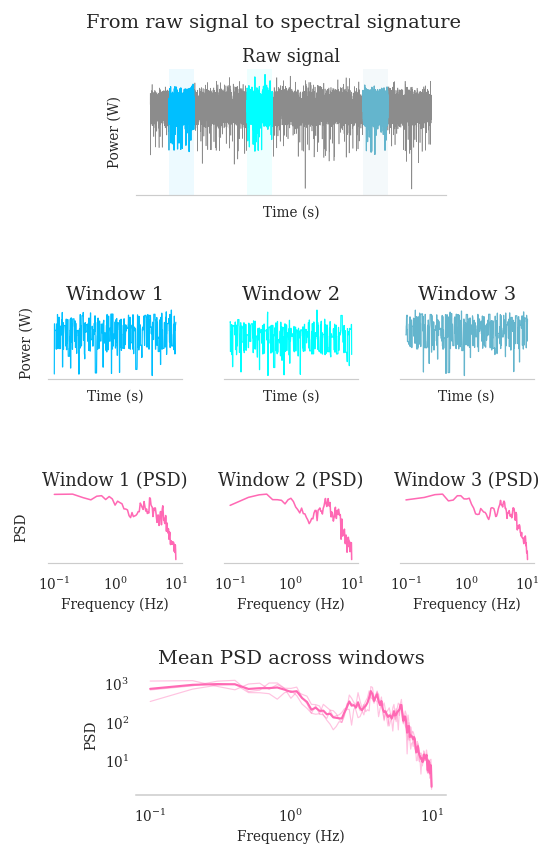

In [53]:
plot_raw_windows_and_mean_psd_for_one_signal(
    resampled_runs=resampled_runs,
    run_name="llm_training",
    signal_type="power",
    target_hz=TARGET_RESAMPLE_HZ,
    window_size_s=WINDOW_SIZE_S,
    start_times_s=[30, 155, 340],
    long_view_duration_s=450,
    title="From raw signal to spectral signature",
)

In [54]:
# =============================================================================
# Example raw windows, per-window PSDs, and mean PSD for one signal
# Horizontal pipeline layout: left -> right
# =============================================================================

def plot_raw_windows_and_mean_psd_for_one_signal(
    resampled_runs: Dict[str, pd.DataFrame],
    run_name: str,
    signal_type: str = "power",
    target_hz: float = TARGET_RESAMPLE_HZ,
    window_size_s: float = 30.0,
    start_times_s: Optional[List[float]] = None,
    long_view_duration_s: float = 150.0,
    title: str = "From raw signal to spectral signature",
    base_long_color: str = "gray",
    window_colors: Optional[List[str]] = None,
    psd_color: str = "hotpink",
    save_path: Optional[str] = None,
) -> None:
    """
    Layout:
        col 1: raw signal centered vertically
        col 2: Window 1 / Window 2 / Window 3 (stacked)
        col 3: Window 1 PSD / Window 2 PSD / Window 3 PSD (stacked)
        col 4: mean PSD centered vertically
    """
    if start_times_s is None:
        start_times_s = [0.0, 15.0, 30.0]

    if len(start_times_s) != 3:
        raise ValueError("start_times_s must contain exactly 3 start times.")

    if window_colors is None:
        window_colors = ["deepskyblue", "cyan", "c"]

    df = resampled_runs[run_name].copy()

    if signal_type not in df.columns:
        raise ValueError(f"{signal_type} not found in resampled run dataframe.")

    # -------------------------------------------------------------------------
    # Long-view data
    # -------------------------------------------------------------------------
    long_end_s = min(long_view_duration_s, float(df["time_s"].max()))
    long_view = df[(df["time_s"] >= 0.0) & (df["time_s"] <= long_end_s)].copy()

    if long_view.empty:
        raise ValueError("Long-view slice is empty.")

    x_long = long_view["time_s"].to_numpy(dtype=float)
    y_long = long_view[signal_type].to_numpy(dtype=float)

    if signal_type == "power" and np.nanmax(y_long) > 10000:
        y_long = y_long / 1000.0

    # -------------------------------------------------------------------------
    # Window data
    # -------------------------------------------------------------------------
    raw_windows = extract_multiple_windows_from_resampled_signal(
        resampled_runs=resampled_runs,
        run_name=run_name,
        signal_type=signal_type,
        window_size_s=window_size_s,
        start_times_s=start_times_s,
    )

    # -------------------------------------------------------------------------
    # Figure / layout
    # -------------------------------------------------------------------------
    plt.rcParams.update({
        "font.family": "serif",
        "axes.linewidth": 0.61,
    })

    fig = plt.figure(figsize=(9.2, 4.8))
    gs = fig.add_gridspec(
        3, 4,
        height_ratios=[1.0, 1.0, 1.0],
        width_ratios=[1.55, 1.0, 1.0, 1.55],
    )

    # raw signal centered vertically
    ax_long = fig.add_subplot(gs[1, 0])

    # windows stacked in one column
    raw_axes = [
        fig.add_subplot(gs[0, 1]),
        fig.add_subplot(gs[1, 1]),
        fig.add_subplot(gs[2, 1]),
    ]

    # psds stacked in one column
    psd_axes = [
        fig.add_subplot(gs[0, 2]),
        fig.add_subplot(gs[1, 2]),
        fig.add_subplot(gs[2, 2]),
    ]

    # mean psd centered vertically
    ax_psd_mean = fig.add_subplot(gs[1, 3])

    # -------------------------------------------------------------------------
    # Column 1: raw signal
    # -------------------------------------------------------------------------
    ax_long.plot(
        x_long,
        y_long,
        color=base_long_color,
        linewidth=0.31,
        zorder=1,
        alpha=0.9,
    )

    for start_s, color in zip(start_times_s, window_colors):
        end_s = start_s + window_size_s
        mask = (x_long >= start_s) & (x_long <= end_s)
        if np.any(mask):
            ax_long.plot(
                x_long[mask],
                y_long[mask],
                color=color,
                linewidth=0.61,
                zorder=3,
            )
            ax_long.axvspan(
                start_s,
                end_s,
                color=color,
                alpha=0.07,
                linewidth=0,
                zorder=0,
            )

    ax_long.set_title("Raw signal", fontsize=10, pad=5)
    ax_long.set_xlabel("Time (s)", fontsize=8, labelpad=2)
    ax_long.set_ylabel("Power (W)", fontsize=8, labelpad=4)

    ax_long.grid(False)
    ax_long.spines["top"].set_visible(False)
    ax_long.spines["right"].set_visible(False)
    ax_long.spines["left"].set_visible(False)
    ax_long.spines["bottom"].set_linewidth(0.61)
    ax_long.tick_params(axis="x", labelsize=7, length=0, width=0.7)
    ax_long.tick_params(axis="y", length=0, width=0.7)
    ax_long.set_xticklabels([])
    ax_long.set_yticklabels([])

    # -------------------------------------------------------------------------
    # Column 2: windows
    # Column 3: PSDs
    # -------------------------------------------------------------------------
    psd_list = []
    freqs_ref = None

    for i, ((ax_raw, ax_psd, (x, y), color)) in enumerate(
        zip(raw_axes, psd_axes, raw_windows, window_colors)
    ):
        if len(x) == 0:
            for ax in [ax_raw, ax_psd]:
                ax.text(
                    0.5, 0.5, "No data",
                    ha="center", va="center",
                    transform=ax.transAxes,
                    fontsize=7,
                )
                ax.set_xticks([])
                ax.set_yticks([])
                for spine in ax.spines.values():
                    spine.set_visible(False)
            continue

        y_plot = y.copy()
        if signal_type == "power" and np.nanmax(y_plot) > 10000:
            y_plot = y_plot / 1000.0

        # --- raw window ---
        ax_raw.plot(x, y_plot, color=color, linewidth=0.61)
        ax_raw.set_title(f"Window {i+1}", fontsize=10, pad=4)
        ax_raw.set_xlabel("Time (s)", fontsize=7, labelpad=2)

        if i == 1:
            ax_raw.set_ylabel("Power (W)", fontsize=7, labelpad=4)
        else:
            ax_raw.set_ylabel("")

        ax_raw.grid(False)
        ax_raw.spines["top"].set_visible(False)
        ax_raw.spines["right"].set_visible(False)
        ax_raw.spines["left"].set_visible(False)
        ax_raw.spines["bottom"].set_linewidth(0.61)
        ax_raw.tick_params(axis="x", labelsize=7, length=0, width=0.7)
        ax_raw.tick_params(axis="y", length=0, width=0.7)
        ax_raw.set_xticklabels([])
        ax_raw.set_yticklabels([])

        # --- PSD of that window ---
        freqs, pxx = compute_single_window_psd(y_plot, fs=target_hz)

        if len(freqs) > 0 and len(pxx) > 0:
            valid = (freqs > 0) & (pxx > 0) & np.isfinite(pxx)
            ax_psd.plot(
                freqs[valid],
                pxx[valid],
                color=psd_color,
                linewidth=0.8,
            )
            ax_psd.set_xscale("log")
            ax_psd.set_yscale("log")

            if freqs_ref is None:
                freqs_ref = freqs
                psd_list.append(pxx)
            elif len(freqs) == len(freqs_ref) and np.allclose(freqs, freqs_ref):
                psd_list.append(pxx)

        ax_psd.set_title(f"Window {i+1} (PSD)", fontsize=9, pad=3)
        ax_psd.set_xlabel("Frequency (Hz)", fontsize=7, labelpad=2)

        if i == 1:
            ax_psd.set_ylabel("PSD", fontsize=7, labelpad=3)
        else:
            ax_psd.set_ylabel("")

        ax_psd.grid(False)
        ax_psd.spines["top"].set_visible(False)
        ax_psd.spines["right"].set_visible(False)
        ax_psd.spines["left"].set_visible(False)
        ax_psd.spines["bottom"].set_linewidth(0.61)
        ax_psd.tick_params(axis="x", labelsize=7, length=3, width=0.7)
        ax_psd.tick_params(axis="y", length=0, width=0.7)
        ax_psd.set_yticklabels([])

    # -------------------------------------------------------------------------
    # Column 4: mean PSD
    # -------------------------------------------------------------------------
    if freqs_ref is not None and len(psd_list) > 0:
        psd_arr = np.vstack(psd_list)
        valid_global = freqs_ref > 0

        for row in psd_arr:
            valid = valid_global & (row > 0) & np.isfinite(row)
            ax_psd_mean.plot(
                freqs_ref[valid],
                row[valid],
                color=psd_color,
                linewidth=0.61,
                alpha=0.4,
            )

        mean_psd = np.nanmean(psd_arr, axis=0)
        valid_mean = valid_global & (mean_psd > 0) & np.isfinite(mean_psd)
        ax_psd_mean.plot(
            freqs_ref[valid_mean],
            mean_psd[valid_mean],
            color=psd_color,
            linewidth=1.1,
            alpha=1.0,
        )

        ax_psd_mean.set_xscale("log")
        ax_psd_mean.set_yscale("log")

    ax_psd_mean.set_title("Mean PSD across windows", fontsize=10, pad=5)
    ax_psd_mean.set_xlabel("Frequency (Hz)", fontsize=8, labelpad=2)
    ax_psd_mean.set_ylabel("PSD", fontsize=8, labelpad=3)

    ax_psd_mean.grid(False)
    ax_psd_mean.spines["top"].set_visible(False)
    ax_psd_mean.spines["right"].set_visible(False)
    ax_psd_mean.spines["left"].set_visible(False)
    ax_psd_mean.spines["bottom"].set_linewidth(0.8)
    ax_psd_mean.tick_params(axis="x", labelsize=7, length=3, width=0.7)
    ax_psd_mean.tick_params(axis="y", labelsize=7, length=0, width=0.7)

    fig.suptitle(title, fontsize=13, y=0.98)

    plt.subplots_adjust(
        left=0.06,
        right=0.98,
        top=0.86,
        bottom=0.14,
        hspace=0.95,
        wspace=0.5,
    )

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

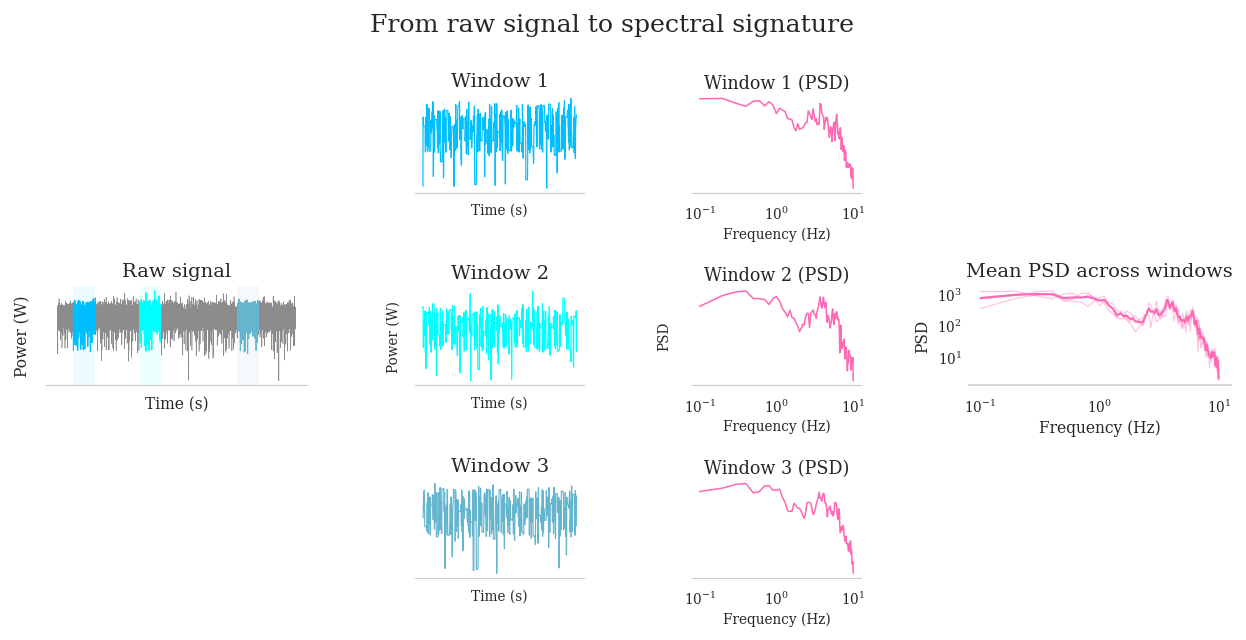

In [55]:
plot_raw_windows_and_mean_psd_for_one_signal(
    resampled_runs=resampled_runs,
    run_name="llm_training",
    signal_type="power",
    target_hz=TARGET_RESAMPLE_HZ,
    window_size_s=WINDOW_SIZE_S,
    start_times_s=[30, 155, 340],
    long_view_duration_s=450,
    title="From raw signal to spectral signature",
)

In [56]:
# =============================================================================
# Plot 5: one-signal comparison across workloads
# =============================================================================

def plot_single_signal_psd_across_workloads(
    psd_results: Dict[str, Dict[str, Dict[str, Any]]],
    signal_type: str,
    run_order: List[str],
    run_display_names: Dict[str, str],
    title: Optional[str] = None,
    save_path: Optional[str] = None,
) -> None:
    red_styles = {
        "llm_training": {"color": "crimson", "linestyle": "-",  "linewidth": 1.2},
        "transformer_non_llm_training": {"color": "hotpink", "linestyle": "--", "linewidth": 1.2},
        "resnet_training": {"color": "plum", "linestyle": "-.", "linewidth": 1.2},
        "llm_inference": {"color": "mediumslateblue", "linestyle": ":",  "linewidth": 1.2},
    }

    if title is None:
        title = f"Spectral comparison for {signal_type}"

    fig, ax = plt.subplots(figsize=(3.6, 2.5))

    for run_name in run_order:
        entry = psd_results.get(run_name, {}).get(signal_type, None)
        if entry is None:
            continue

        freqs = entry["freqs"]
        psd_windows = entry["psd_windows"]

        if len(freqs) == 0 or psd_windows.size == 0:
            continue

        mean_psd = np.nanmean(psd_windows, axis=0)
        valid = (freqs > 0) & (mean_psd > 0) & np.isfinite(mean_psd)

        style = red_styles[run_name]
        ax.plot(
            freqs[valid],
            mean_psd[valid],
            color=style["color"],
            linestyle=style["linestyle"],
            linewidth=style["linewidth"],
            solid_capstyle="round",
            label=run_display_names[run_name],
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(title, fontsize=10, pad=6)
    ax.set_xlabel("Frequency (Hz)", fontsize=8)
    ax.set_ylabel("PSD", fontsize=8, labelpad=4)
    ax.spines["left"].set_visible(False)
    _clean_editorial_axes(ax, hide_left_spine=False)
    ax.legend(
        frameon=False,
        fontsize=8,
        loc="lower left",
        ncol=2,
        handletextpad=0.4,
        columnspacing=1.2,
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

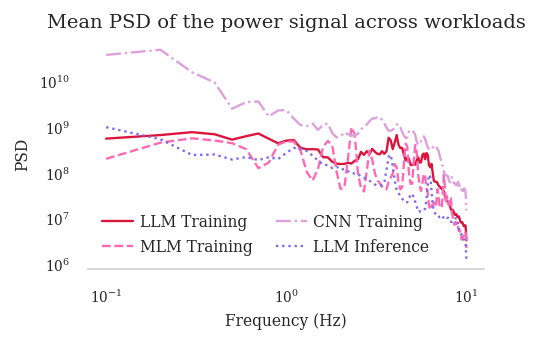

In [57]:
plot_single_signal_psd_across_workloads(
    psd_results=psd_results,
    signal_type="power",
    run_order=WORKLOAD_ORDER,
    run_display_names=RUN_DISPLAY_NAMES,
    title="Mean PSD of the power signal across workloads",
)

In [58]:
# =============================================================================
# Plot 6: full spectral comparison across all signals
# =============================================================================

def plot_all_signals_psd_red_editorial(
    psd_results: Dict[str, Dict[str, Dict[str, Any]]],
    signals: List[str],
    run_order: List[str],
    run_display_names: Dict[str, str],
    title: str = "Spectral comparison across workloads",
    save_path: Optional[str] = None,
) -> None:
    red_styles = {
        "llm_training": {"color": "crimson", "linestyle": "-",  "linewidth": 1.2},
        "transformer_non_llm_training": {"color": "hotpink", "linestyle": "--", "linewidth": 1.2},
        "resnet_training": {"color": "plum", "linestyle": "-.", "linewidth": 1.2},
        "llm_inference": {"color": "mediumslateblue", "linestyle": ":",  "linewidth": 1.2},
    }

    pretty_signal_names = {
        "gpu_util": "GPU utilization",
        "power": "Power",
        "temperature": "Temperature",
        "sm_clock": "SM clock",
        "pcie_tx": "PCIe TX",
    }

    ncols = len(signals)
    fig, axes = plt.subplots(
        1, ncols,
        figsize=(2.4 * ncols, 2.1),
        squeeze=False
    )
    axes = axes[0]

    for ax, signal_type in zip(axes, signals):
        for run_name in run_order:
            entry = psd_results.get(run_name, {}).get(signal_type, None)
            if entry is None:
                continue

            freqs = entry["freqs"]
            psd_windows = entry["psd_windows"]

            if len(freqs) == 0 or psd_windows.size == 0:
                continue

            mean_psd = np.nanmean(psd_windows, axis=0)
            valid = (freqs > 0) & (mean_psd > 0) & np.isfinite(mean_psd)

            style = red_styles[run_name]
            ax.plot(
                freqs[valid],
                mean_psd[valid],
                color=style["color"],
                linestyle=style["linestyle"],
                linewidth=style["linewidth"],
                solid_capstyle="round",
                label=run_display_names[run_name],
            )

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_title(pretty_signal_names.get(signal_type, signal_type), fontsize=13, pad=6)

        if ax is axes[0]:
            ax.set_ylabel("PSD", fontsize=13, labelpad=4)
        else:
            ax.set_ylabel("")

       # ax.set_xlabel("Frequency (Hz)", fontsize=13, labelpad=3)
        ax.spines["left"].set_visible(False)
        _clean_editorial_axes(ax, hide_left_spine=False)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=min(len(handles), 4),
        frameon=False,
        fontsize=13,
        handlelength=1.8,
        handletextpad=0.5,
        columnspacing=1.4,
        bbox_to_anchor=(0.5, -0.08),
    )

    fig.suptitle(title, fontsize=15, y=1.0)

    plt.subplots_adjust(
        left=0.07,
        right=0.995,
        bottom=0.23,
        top=0.78,
        wspace=0.35,
    )

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()



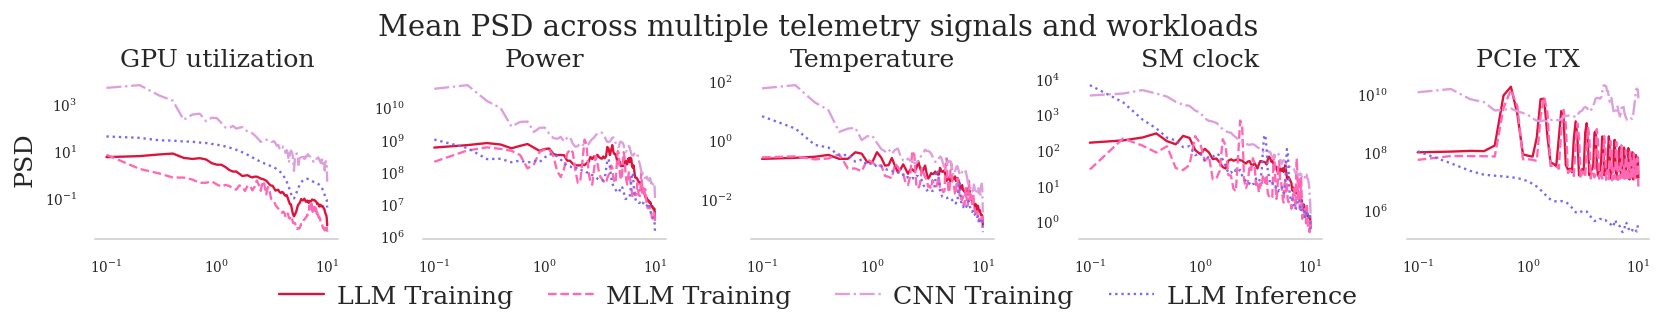

In [59]:
plot_all_signals_psd_red_editorial(
    psd_results=psd_results,
    signals=PRIMARY_SIGNALS,
    run_order=WORKLOAD_ORDER,
    run_display_names=RUN_DISPLAY_NAMES,
    title="Mean PSD across multiple telemetry signals and workloads",
)

## **Window-level representation learning**

In [62]:
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D
from sklearn.preprocessing import StandardScaler

def extract_window_feature_table(
    X: np.ndarray,
    meta_df: pd.DataFrame,
    signals: List[str],
    target_hz: float,
) -> pd.DataFrame:
    """
    Extract simple statistical features from each window.

    Returns a DataFrame with one row per window and columns:
    signal__feature
    """

    n_windows, n_channels, window_len = X.shape

    rows = []

    for i in range(n_windows):
        row = {}

        for s_idx, signal in enumerate(signals):
            series = X[i, s_idx, :]

            row[f"{signal}__mean"] = np.mean(series)
            row[f"{signal}__std"] = np.std(series)
            row[f"{signal}__min"] = np.min(series)
            row[f"{signal}__max"] = np.max(series)

        rows.append(row)

    feat_df = pd.DataFrame(rows)

    # junta com metadata (run_name etc)
    feat_df = pd.concat([meta_df.reset_index(drop=True), feat_df], axis=1)

    return feat_df

In [63]:
def plot_window_embedding_pca(
    feature_df: pd.DataFrame,
    feature_cols: List[str],
    label_col: str = "run_display_name",
    crop_quantiles: Tuple[float, float] = (0.01, 0.99),
    save_path: Optional[str] = None,
) -> Tuple[pd.DataFrame, PCA]:
    """
    Fit PCA on the selected feature columns and plot the first two components.

    Colors are hardcoded by run_type to avoid label-matching issues.
    """
    X_feat = feature_df[feature_cols].to_numpy(dtype=float)
    X_feat = np.nan_to_num(X_feat, nan=0.0, posinf=0.0, neginf=0.0)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_feat)

    pca = PCA(n_components=2, random_state=7)
    emb = pca.fit_transform(X_scaled)

    plot_df = feature_df.copy()
    plot_df["pc1"] = emb[:, 0]
    plot_df["pc2"] = emb[:, 1]

    plt.rcParams.update({
        "font.family": "serif",
        "axes.linewidth": 0.8,
    })

    # Hardcoded colors by internal run_type
    workload_colors = {
        "llm_training": "crimson",
        "transformer_non_llm_training": "mediumslateblue",
        "resnet_training": "hotpink",
        "llm_inference": "plum",
    }

    # Hardcoded legend names by internal run_type
    workload_labels = {
        "llm_training": "LLM Training",
        "transformer_non_llm_training": "MLM Training",
        "resnet_training": "CNN Training",
        "llm_inference": "LLM Inference",
    }

    workload_order = [
        "llm_training",
        "transformer_non_llm_training",
        "resnet_training",
        "llm_inference",
    ]

    fig, ax = plt.subplots(figsize=(4.4, 4.4))

    for run_type in workload_order:
        sub = plot_df[plot_df["run_name"] == run_type]

        if sub.empty:
            continue

        ax.scatter(
            sub["pc1"],
            sub["pc2"],
            s=20,
            alpha=0.7,
            color=workload_colors[run_type],
            label=workload_labels[run_type],
            edgecolors="none",
        )

    ax.set_xlabel(f"PC1 ({100 * pca.explained_variance_ratio_[0]:.1f}%)", fontsize=13, labelpad=4)
    ax.set_ylabel(f"PC2 ({100 * pca.explained_variance_ratio_[1]:.1f}%)", fontsize=13, labelpad=4)
    ax.set_title("Clustering of telemetry windows", fontsize=14, pad=5)

    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(axis="x", length=0, width=0.7)
    ax.tick_params(axis="y", length=0, width=0.7)

    q_low, q_high = crop_quantiles

    x_lo = np.quantile(plot_df["pc1"], q_low)
    x_hi = np.quantile(plot_df["pc1"], q_high)
    y_lo = np.quantile(plot_df["pc2"], q_low)
    y_hi = np.quantile(plot_df["pc2"], q_high)

    x_pad = 0.06 * (x_hi - x_lo) if x_hi > x_lo else 1.0
    y_pad = 0.06 * (y_hi - y_lo) if y_hi > y_lo else 1.0

    ax.set_xlim(x_lo - x_pad, x_hi + x_pad)
    ax.set_ylim(y_lo - y_pad, y_hi + y_pad)

    legend_handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            markersize=6,
            markerfacecolor=workload_colors[run_type],
            markeredgecolor="none",
            alpha=1.0,
            label=workload_labels[run_type],
        )
        for run_type in workload_order
        if run_type in plot_df["run_name"].values
    ]

    ax.legend(
        handles=legend_handles,
        frameon=False,
        fontsize=10,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.20),
        ncol=2,
        handletextpad=0.4,
        borderpad=0.2,
    )

    plt.tight_layout()
    plt.subplots_adjust(right=0.77)

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    return plot_df, pca

In [64]:
feature_df = extract_window_feature_table(
    X=X,
    meta_df=windows_meta_df,
    signals=PRIMARY_SIGNALS,
    target_hz=TARGET_RESAMPLE_HZ,
)

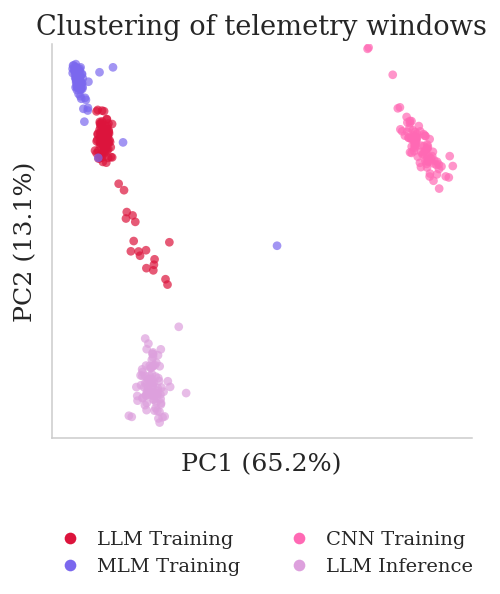

In [65]:
feature_cols = [c for c in feature_df.columns if "__" in c]

plot_df, pca = plot_window_embedding_pca(
    feature_df=feature_df,
    feature_cols=feature_cols,
)

## **MiniRocket binary classification** (can be updated when more runs are available)

### **Binary test: LLM Training vs others**

In [66]:
# =============================================================================
# MiniRocket binary classification
# =============================================================================

minirocket_clf = MiniRocketClassifier(
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

minirocket_clf.fit(X_train, y_train)
y_pred = minirocket_clf.predict(X_test)


Accuracy:          1.0000
Balanced accuracy: 1.0000

                  precision    recall  f1-score   support

    LLM Training     1.0000    1.0000    1.0000        33
Not LLM Training     1.0000    1.0000    1.0000        84

        accuracy                         1.0000       117
       macro avg     1.0000    1.0000    1.0000       117
    weighted avg     1.0000    1.0000    1.0000       117



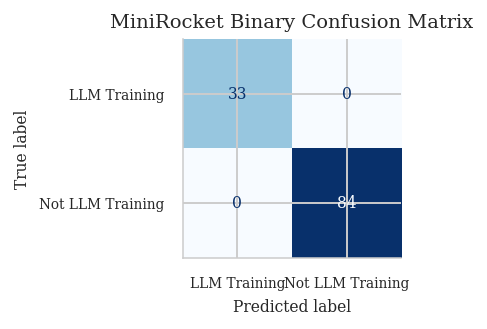

In [67]:

# =============================================================================
# Binary results
# =============================================================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

acc = accuracy_score(y_test, y_pred)
bal_acc = balanced_accuracy_score(y_test, y_pred)

print(f"Accuracy:          {acc:.4f}")
print(f"Balanced accuracy: {bal_acc:.4f}")
print()
print(classification_report(y_test, y_pred, digits=4))


labels_bin = ["LLM Training", "Not LLM Training"]
cm = confusion_matrix(y_test, y_pred, labels=labels_bin)

fig, ax = plt.subplots(figsize=(3, 3))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_bin)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("MiniRocket Binary Confusion Matrix")
plt.tight_layout()
plt.show()


A simple time-series classifier can perfectly distinguish LLM training from other workloads when evaluated on non-overlapping, temporally separated windows from the same steady-state runs.

E depois:

This suggests that the telemetry signature is highly stable over time and strongly separable within the observed runs.

### **Binary test: LLM Training vs Transformer non-LLM Training**

In [68]:
# =============================================================================
# Binary experiment: LLM Training vs Transformer non-LLM Training
# =============================================================================

PAIR_RUNS = ["llm_training", "transformer_non_llm_training"]

PAIR_DISPLAY_NAMES = {
    "llm_training": "LLM Training",
    "transformer_non_llm_training": "Transformer non-LLM Training",
}

def build_window_dataset_for_selected_runs(
    resampled_runs: Dict[str, pd.DataFrame],
    selected_runs: List[str],
    signals: List[str] = PRIMARY_SIGNALS,
    window_size_s: float = WINDOW_SIZE_S,
    window_step_s: float = WINDOW_STEP_S,
    target_hz: float = TARGET_RESAMPLE_HZ,
) -> Tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    """
    Build a multivariate equal-length window dataset in aeon format
    using only the selected runs.
    """
    window_len = int(round(window_size_s * target_hz))
    step_len = int(round(window_step_s * target_hz))

    X_list = []
    y_list = []
    meta_rows = []

    for run_name in selected_runs:
        df = resampled_runs[run_name].copy()
        values = df[signals].to_numpy(dtype=np.float32)
        times = df["time_s"].to_numpy(dtype=float)

        n = len(df)
        if n < window_len:
            continue

        starts = np.arange(0, n - window_len + 1, step_len, dtype=int)

        for i, start_idx in enumerate(starts):
            end_idx = start_idx + window_len
            window = values[start_idx:end_idx]   # shape: (T, C)
            window = window.T                    # shape: (C, T)

            X_list.append(window)
            y_list.append(PAIR_DISPLAY_NAMES[run_name])

            meta_rows.append({
                "run_name": run_name,
                "run_display_name": RUN_DISPLAY_NAMES[run_name],
                "pair_label": PAIR_DISPLAY_NAMES[run_name],
                "window_id_within_run": i,
                "start_idx": int(start_idx),
                "end_idx": int(end_idx - 1),
                "start_s": float(times[start_idx]),
                "end_s": float(times[end_idx - 1]),
            })

    X_pair = np.stack(X_list, axis=0)
    y_pair = np.asarray(y_list)
    meta_pair_df = pd.DataFrame(meta_rows)

    return X_pair, y_pair, meta_pair_df


X_pair, y_pair, meta_pair_df = build_window_dataset_for_selected_runs(
    resampled_runs=resampled_runs,
    selected_runs=PAIR_RUNS,
    signals=PRIMARY_SIGNALS,
    window_size_s=WINDOW_SIZE_S,
    window_step_s=WINDOW_STEP_S,
    target_hz=TARGET_RESAMPLE_HZ,
)

print("X_pair shape:", X_pair.shape)
print("y_pair shape:", y_pair.shape)
display(meta_pair_df.head())
display(pd.crosstab(meta_pair_df["run_display_name"], meta_pair_df["pair_label"]))

X_pair shape: (199, 5, 800)
y_pair shape: (199,)


,run_name,run_display_name,pair_label,window_id_within_run,start_idx,end_idx,start_s,end_s
0,llm_training,LLM Training,LLM Training,0,0,799,0.0,39.95
1,llm_training,LLM Training,LLM Training,1,800,1599,40.0,79.95
2,llm_training,LLM Training,LLM Training,2,1600,2399,80.0,119.95
3,llm_training,LLM Training,LLM Training,3,2400,3199,120.0,159.95
4,llm_training,LLM Training,LLM Training,4,3200,3999,160.0,199.95


pair_label,LLM Training,Transformer non-LLM Training
run_display_name,,
LLM Training,110,0
MLM Training,0,89


In [69]:
# =============================================================================
# Temporal split with gap for the pairwise experiment
# =============================================================================

def make_blocked_temporal_split_with_gap_for_selected_runs(
    meta_df: pd.DataFrame,
    selected_runs: List[str],
    train_fraction: float = 0.6,
    gap_fraction: float = 0.1,
) -> pd.DataFrame:
    """
    Temporal blocked split within each selected run:
    - early windows -> train
    - middle windows -> discarded gap
    - later windows -> test
    """
    meta_df = meta_df.copy()
    meta_df["split"] = "discard"

    for run_name in selected_runs:
        idx = meta_df.index[meta_df["run_name"] == run_name].to_numpy()
        idx_sorted = idx[np.argsort(meta_df.loc[idx, "start_s"].to_numpy())]

        n = len(idx_sorted)
        if n < 3:
            raise ValueError(f"Not enough windows for run: {run_name}")

        n_train = int(np.floor(train_fraction * n))
        n_gap = int(np.floor(gap_fraction * n))

        train_end = n_train
        gap_end = min(n, train_end + n_gap)

        train_idx = idx_sorted[:train_end]
        test_idx = idx_sorted[gap_end:]

        meta_df.loc[train_idx, "split"] = "train"
        meta_df.loc[test_idx, "split"] = "test"

    return meta_df


meta_pair_df = make_blocked_temporal_split_with_gap_for_selected_runs(
    meta_pair_df,
    selected_runs=PAIR_RUNS,
    train_fraction=0.6,
    gap_fraction=0.1,
)

display(meta_pair_df["split"].value_counts())
display(pd.crosstab(meta_pair_df["run_display_name"], meta_pair_df["split"]))
display(pd.crosstab(meta_pair_df["pair_label"], meta_pair_df["split"]))

,count
split,
train,119
test,61
discard,19


split,discard,test,train
run_display_name,,,
LLM Training,11,33,66
MLM Training,8,28,53


split,discard,test,train
pair_label,,,
LLM Training,11,33,66
Transformer non-LLM Training,8,28,53


In [70]:
# =============================================================================
# Train/test arrays for the pairwise experiment
# =============================================================================

train_mask_pair = meta_pair_df["split"].to_numpy() == "train"
test_mask_pair = meta_pair_df["split"].to_numpy() == "test"

X_train_pair = X_pair[train_mask_pair]
y_train_pair = y_pair[train_mask_pair]

X_test_pair = X_pair[test_mask_pair]
y_test_pair = y_pair[test_mask_pair]

train_pair_meta_df = meta_pair_df.loc[train_mask_pair].reset_index(drop=True)
test_pair_meta_df = meta_pair_df.loc[test_mask_pair].reset_index(drop=True)

print("Train pair:", X_train_pair.shape, y_train_pair.shape)
print("Test pair: ", X_test_pair.shape, y_test_pair.shape)

Train pair: (119, 5, 800) (119,)
Test pair:  (61, 5, 800) (61,)


In [71]:
# =============================================================================
# MiniRocket pairwise classification
# =============================================================================

pair_clf = MiniRocketClassifier(
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

pair_clf.fit(X_train_pair, y_train_pair)
y_pred_pair = pair_clf.predict(X_test_pair)

In [72]:
# =============================================================================
# Pairwise results
# =============================================================================

acc_pair = accuracy_score(y_test_pair, y_pred_pair)
bal_acc_pair = balanced_accuracy_score(y_test_pair, y_pred_pair)

print(f"Pairwise accuracy:          {acc_pair:.4f}")
print(f"Pairwise balanced accuracy: {bal_acc_pair:.4f}")
print()
print(classification_report(y_test_pair, y_pred_pair, digits=4))

Pairwise accuracy:          1.0000
Pairwise balanced accuracy: 1.0000

                              precision    recall  f1-score   support

                LLM Training     1.0000    1.0000    1.0000        33
Transformer non-LLM Training     1.0000    1.0000    1.0000        28

                    accuracy                         1.0000        61
                   macro avg     1.0000    1.0000    1.0000        61
                weighted avg     1.0000    1.0000    1.0000        61



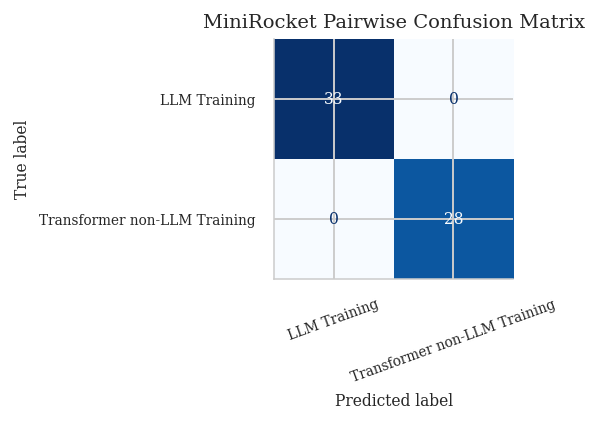

In [73]:
pair_labels = [
    "LLM Training",
    "Transformer non-LLM Training",
]

cm_pair = confusion_matrix(y_test_pair, y_pred_pair, labels=pair_labels)

fig, ax = plt.subplots(figsize=(3.8, 3.8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_pair, display_labels=pair_labels)
disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=20)
ax.set_title("MiniRocket Pairwise Confusion Matrix")
plt.tight_layout()
plt.show()

In [74]:
pair_results_df = test_pair_meta_df[[
    "run_name",
    "run_display_name",
    "pair_label",
    "start_s",
    "end_s",
]].copy()

pair_results_df["y_true"] = y_test_pair
pair_results_df["y_pred"] = y_pred_pair
pair_results_df["correct"] = pair_results_df["y_true"] == pair_results_df["y_pred"]

display(pair_results_df.head())
display(pd.crosstab(pair_results_df["run_display_name"], pair_results_df["correct"]))
display(pd.crosstab(pair_results_df["y_true"], pair_results_df["y_pred"]))

,run_name,run_display_name,pair_label,start_s,end_s,y_true,y_pred,correct
0,llm_training,LLM Training,LLM Training,3080.0,3119.95,LLM Training,LLM Training,True
1,llm_training,LLM Training,LLM Training,3120.0,3159.95,LLM Training,LLM Training,True
2,llm_training,LLM Training,LLM Training,3160.0,3199.95,LLM Training,LLM Training,True
3,llm_training,LLM Training,LLM Training,3200.0,3239.95,LLM Training,LLM Training,True
4,llm_training,LLM Training,LLM Training,3240.0,3279.95,LLM Training,LLM Training,True


correct,True
run_display_name,
LLM Training,33
MLM Training,28


y_pred,LLM Training,Transformer non-LLM Training
y_true,,
LLM Training,33,0
Transformer non-LLM Training,0,28


### **Binary test: LLM Training vs Transformer non-LLM Training (power sensor only; gpu sensor only)**

In [75]:
def run_pairwise_experiment_for_signals(
    resampled_runs: Dict[str, pd.DataFrame],
    selected_runs: List[str],
    signals: List[str],
    window_size_s: float = WINDOW_SIZE_S,
    window_step_s: float = WINDOW_STEP_S,
    target_hz: float = TARGET_RESAMPLE_HZ,
    train_fraction: float = 0.6,
    gap_fraction: float = 0.1,
    random_state: int = RANDOM_STATE,
) -> Dict[str, Any]:
    """
    Run the pairwise within-run temporal generalization experiment
    for a selected subset of signals.
    """
    X_pair, y_pair, meta_pair_df = build_window_dataset_for_selected_runs(
        resampled_runs=resampled_runs,
        selected_runs=selected_runs,
        signals=signals,
        window_size_s=window_size_s,
        window_step_s=window_step_s,
        target_hz=target_hz,
    )

    meta_pair_df = make_blocked_temporal_split_with_gap_for_selected_runs(
        meta_df=meta_pair_df,
        selected_runs=selected_runs,
        train_fraction=train_fraction,
        gap_fraction=gap_fraction,
    )

    train_mask = meta_pair_df["split"].to_numpy() == "train"
    test_mask = meta_pair_df["split"].to_numpy() == "test"

    X_train = X_pair[train_mask]
    y_train = y_pair[train_mask]
    X_test = X_pair[test_mask]
    y_test = y_pair[test_mask]

    clf = MiniRocketClassifier(
        n_jobs=-1,
        random_state=random_state,
    )

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)

    return {
        "signals": signals,
        "n_train": len(y_train),
        "n_test": len(y_test),
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "y_test": y_test,
        "y_pred": y_pred,
        "meta_df": meta_pair_df,
    }

In [76]:
# =============================================================================
# Single-sensor tests: power only and GPU utilization only
# =============================================================================

PAIR_RUNS = ["llm_training", "transformer_non_llm_training"]

single_sensor_settings = {
    "power_only": ["power"],
    "gpu_util_only": ["gpu_util"],
}

single_sensor_results = {}

rows = []

for setting_name, signals in single_sensor_settings.items():
    result = run_pairwise_experiment_for_signals(
        resampled_runs=resampled_runs,
        selected_runs=PAIR_RUNS,
        signals=signals,
    )

    single_sensor_results[setting_name] = result

    rows.append({
        "setting": setting_name,
        "signals": ", ".join(signals),
        "n_train": result["n_train"],
        "n_test": result["n_test"],
        "accuracy": result["accuracy"],
        "balanced_accuracy": result["balanced_accuracy"],
    })

single_sensor_df = pd.DataFrame(rows).sort_values(
    by="balanced_accuracy",
    ascending=False,
    kind="stable",
).reset_index(drop=True)

display(single_sensor_df)

,setting,signals,n_train,n_test,accuracy,balanced_accuracy
0,power_only,power,119,61,1.0,1.0
1,gpu_util_only,gpu_util,119,61,1.0,1.0


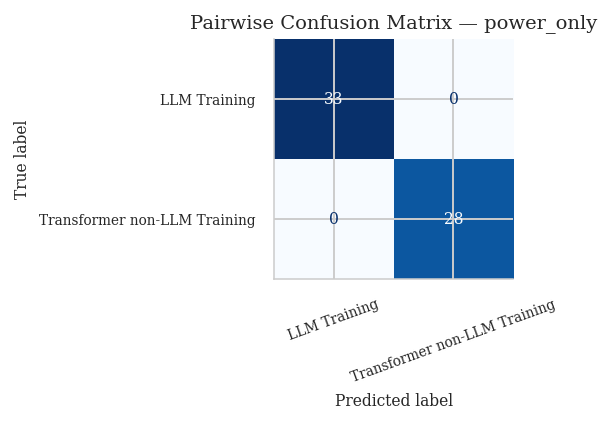

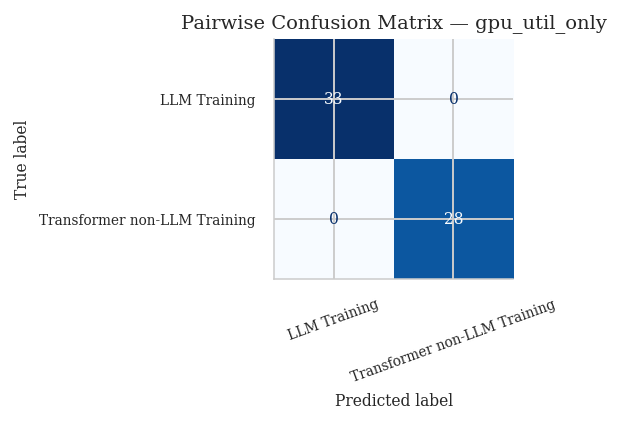

In [77]:
pair_labels = ["LLM Training", "Transformer non-LLM Training"]

for setting_name in ["power_only", "gpu_util_only"]:
    result = single_sensor_results[setting_name]

    cm = confusion_matrix(
        result["y_test"],
        result["y_pred"],
        labels=pair_labels,
    )

    fig, ax = plt.subplots(figsize=(3.8, 3.8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pair_labels)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=20)
    ax.set_title(f"Pairwise Confusion Matrix — {setting_name}")
    plt.tight_layout()
    plt.show()

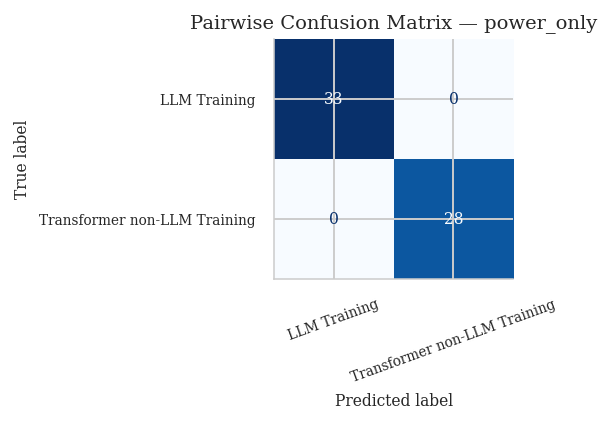

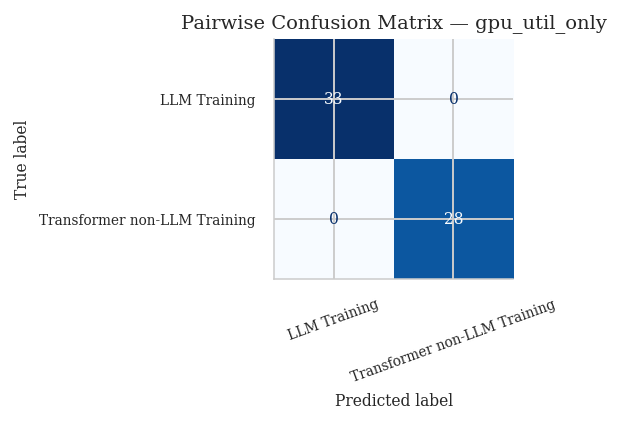

In [78]:
pair_labels = ["LLM Training", "Transformer non-LLM Training"]

for setting_name in ["power_only", "gpu_util_only"]:
    result = single_sensor_results[setting_name]

    cm = confusion_matrix(
        result["y_test"],
        result["y_pred"],
        labels=pair_labels,
    )

    fig, ax = plt.subplots(figsize=(3.8, 3.8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pair_labels)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=20)
    ax.set_title(f"Pairwise Confusion Matrix — {setting_name}")
    plt.tight_layout()
    plt.show()